### <b>Load packages</b>

In [2]:
import pandas as pd
import numpy as np
import os
import re

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.transforms as transforms
from matplotlib.colors import to_rgb, to_hex

import plotly.graph_objects as go
import plotly.io as pio
from PIL import Image

### <b>Define parameters and file info</b>

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
data_directory = r"..\data\nonprofit_economy"

# -----------------------------------------------------------------------
# CSV data for network diagram
# -----------------------------------------------------------------------

node_file = r"MCN_nonprofit_economy_revenue_nodes_2023.csv"
node_path = os.path.join(data_directory, node_file)
print("Node CSV file:", node_path)
if os.path.exists(node_path):
    print("EXISTS")

edge_file = r"MCN_nonprofit_economy_revenue_edges_2023.csv"
edge_path = os.path.join(data_directory, edge_file)
print("Edge CSV file:", edge_path)
if os.path.exists(edge_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# CSV data for revenue & asset graphs
# -----------------------------------------------------------------------

asset_file = r"MCN_nonprofit_economy_assets_bar_2023.csv"
asset_path = os.path.join(data_directory, asset_file)
print("Assets CSV file:", asset_path)
if os.path.exists(asset_path):
    print("EXISTS")

rev_file = r"MCN_nonprofit_economy_revenue_bar_2023.csv"
rev_path = os.path.join(data_directory, rev_file)
print("Revenue CSV file:", rev_path)
if os.path.exists(rev_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# CSV data for intermediary graphs
# -----------------------------------------------------------------------

im_file = r"MCN_nonprofit_economy_intermediary_cga_2023.csv"
im_path = os.path.join(data_directory, im_file)
print("Intermediaries CSV file:", im_path)
if os.path.exists(im_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------

output_directory = r"..\figures"

# Sankey output files
sankey_poster_file = "USINE_sankey_poster"
sankey_web_interactive_file = "USINE_sankey_interactive"
sankey_web_static_file = "USINE_sankey_static"
sankey_web_static_with_bars_file = "USINE_sankey_static_with_bars"

# Bar graph output files
assets_file = "USINE_assets_by_activity_area_2023"
revenue_file = "USINE_revenue_trends_by_activity_area_2023"
assets_sideways_file = "USINE_assets_by_activity_area_2023_sideways"
revenue_sideways_file = "USINE_revenue_trends_by_activity_area_2023_sideways"

# Intermediary output files
daf_file = "USINE_intermediary_daf_trends"
pf_file = "USINE_intermediary_pf_trends"

Node CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_nodes_2023.csv
EXISTS
Edge CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_edges_2023.csv
EXISTS
Assets CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_assets_bar_2023.csv
EXISTS
Revenue CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_bar_2023.csv
EXISTS
Intermediaries CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_intermediary_cga_2023.csv
EXISTS


### <b>Define functions</b>

In [5]:
# Define function to save figure

def save_figure(fig, filename, dpi=300):

    output_path = os.path.join(output_directory, filename + ".png")

    fig.savefig(
        # filename,
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.01
    )

### <b>Color and font settings</b>

In [6]:
# Color settings

custom_alpha = 0.35

# Bar graph colors
network_blue = "#6EAAE6"
network_gray = "#898989"
background_color = "#F5F5F5"
spine_color = "#BDBDBD"

# Intermediary colors
daf_color = "#962F3F"
pf_color = "#244477"

recipient_node_color = "#B4B4B4"
node_outline_color = "#666666"

# Rainbow colors
rainbow_color_1 = "#A0A0A0"
rainbow_color_2 = "#E66E6E"
rainbow_color_3 = "#E6AA6E"
rainbow_color_4 = "#E6D26E"
rainbow_color_5 = "#A0CD78"
rainbow_color_6 = "#78BEAA"
rainbow_color_7 = "#6EAAE6"
rainbow_color_8 = "#AA6EE6"

# Funding source colors
source_colors = [
    rainbow_color_1,  # gray
    rainbow_color_2,  # pink
    rainbow_color_3,  # orange
    rainbow_color_4,  # yellow
    rainbow_color_5,  # green
    rainbow_color_6,  # teal
    rainbow_color_7,  # blue
    rainbow_color_8,  # purple
]

category_palette_index = {
    "Program fees from private sources": 0,
    "Federal government": 1,
    "State and local government": 2,
    "Federated Giving": 3,
    "Investment Income": 4,
    "Corporations": 5,
    "Bequests": 6,
    "Individuals": 7,
}

In [7]:
# Font settings

# Font sizes for sankey flow chart
poster_titlesize = 26
poster_node_titlesize = 16
poster_data_labelsize = 10

# Font sizes for bar graphs for poster
bar_poster_titlesize = 18
bar_poster_axis_labelsize = 16
bar_poster_data_labelsize = 16
bar_poster_caption_size = 10

# Font sizes for intermediary graphs for poster
im_poster_titlesize = 18
im_poster_axis_labelsize = 16
im_poster_data_labelsize = 16
im_poster_caption_size = 10

# Font sizes for web bar graphs
bar_axis_titlesize = 12
bar_axis_labelsize = 9
bar_facet_titlesize = 9
bar_caption_size = 8

# Font sizes for paper
# axis_titlesize = 18
# axis_labelsize = 14
# facet_titlesize = 14
# caption_size = 10

# Font sizes for powerpoint
# ppt_axis_titlesize = 14
# ppt_axis_labelsize = 14
# ppt_facet_titlesize = 16
# ppt_caption_size = 12
# ppt_titlesize = 20

# Set font family

# font_family = "Source Sans 3, Helvetica Neue, Arial, sans-serif"
# font_family = "Inter, Segoe UI, Roboto, Arial, sans-serif"
font_family = ["Arial", "sans-serif"]
# bar_font_family = ["Arial", "Source Sans 3", "Helvetica Neue", "sans-serif"]
bar_font_family = ["Arial", "sans-serif"]

# Create CSS font family version
font_family_css = ", ".join(
    f'"{f.strip()}"' if " " in f.strip() else f.strip()
    for f in font_family
)

# GLOBAL DEFAULT SEABORN STYLE SETTINGS

sns.set(
    style="whitegrid",
    rc={
        "axes.labelsize": bar_poster_axis_labelsize,
        "xtick.labelsize": bar_poster_axis_labelsize,
        "ytick.labelsize": bar_poster_axis_labelsize,
    }
)

In [8]:
# Function to darken a color
def darken_color(color, factor=0.95):
    """
    Make an rgba(...) or hex color darker.
    
    factor = 1.0 -> original RGB brightness
    factor = 0.65 -> moderately darker
    factor = 0.4 -> substantially darker
    """
    
    # Handle rgba(r,g,b,a) strings
    if isinstance(color, str) and color.startswith("rgba"):
        
        values = re.findall(r"[\d.]+", color)
        
        r = float(values[0])
        g = float(values[1])
        b = float(values[2])
        
        darker_rgb = (
            r / 255 * factor,
            g / 255 * factor,
            b / 255 * factor
        )
        
        return to_hex(darker_rgb)
    
    # Handle ordinary hex colors
    else:
        rgb = to_rgb(color)
        darker_rgb = tuple(c * factor for c in rgb)
        return to_hex(darker_rgb)

### <b>Load data</b>

In [9]:
# Load nonprofit economy node data

node_raw_df = pd.read_csv(node_path)
node_raw_df.head()

,Node,Node Type,X,Y,X Offset,Y Offset
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.007
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.000
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.010
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.000
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.037


In [10]:
# Load nonprofit economy edge data

edge_raw_df = pd.read_csv(edge_path)
edge_raw_df.head()

,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92


In [11]:
# Load nonprofit economy asset bar graph data

asset_raw_df = pd.read_csv(asset_path)
asset_raw_df.head()

,Activity Area Original,Activity Area,Total
0,"Arts, Culture, Humanities",Arts & culture,1.870000e+11
1,Education,Other education,6.290000e+11
2,Colleges and Universities,Colleges/universities,9.500000e+11
3,Environment and Animals,Environment/animals,7.894316e+10
4,Health,Other healthcare,5.440000e+11


In [12]:
# Load nonprofit economy revenue bar graph data

revenue_raw_df = pd.read_csv(rev_path)
revenue_raw_df.head()

,Activity Area Original,Activity Area,Year,Revenue Adjusted for Inflation
0,Hospitals and nursing homes,Hospitals/nursing homes,2006,895
1,Hospitals and nursing homes,Hospitals/nursing homes,2009,896
2,Hospitals and nursing homes,Hospitals/nursing homes,2015,"1,239"
3,Hospitals and nursing homes,Hospitals/nursing homes,2023,"1,296"
4,Higher Education,Colleges/universities,2006,242


In [13]:
# Load nonprofit economy intermediary graph data

im_raw_df = pd.read_csv(im_path)
im_raw_df.head()

,Intermediary,Metric,Year,990 Value,Other Value
0,Private foundations,Assets,2020,1042859557935,NaN
1,Private foundations,Assets,2021,1329097595552,NaN
2,Private foundations,Assets,2022,1310018903478,NaN
3,Private foundations,Assets,2023,1413679354149,NaN
4,Private foundations,Assets,2024,1571657502587,NaN


### <b>Clean up data for Sankey diagram</b>

#### Clean up data in network diagram dataframes

In [14]:
# Clean & format columns in edge data

edge_clean_df = edge_raw_df.copy()

edge_clean_df["Amount"] = pd.to_numeric(
    edge_clean_df["Amount"]
        .replace("-", 0)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

print(len(edge_clean_df))
edge_clean_df.head()

132


,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92


In [15]:
edge_clean_df[edge_clean_df["Source"].str.contains("Program")].head(10)

,Source,Recipient,Amount
106,Program fees from private sources,"Arts, culture, humanities",14.70
107,Program fees from private sources,Education (minus colleges and universities),78.61
108,Program fees from private sources,Colleges and universities,194.10
109,Program fees from private sources,Environment and animals,7.30
110,Program fees from private sources,Health (minus hospitals and nursing homes),219.66
111,Program fees from private sources,Hospitals and nursing homes,1207.49
112,Program fees from private sources,Human Services,148.38
113,Program fees from private sources,International/foreign affairs,3.26
114,Program fees from private sources,Public/societal benefit (minus national DAF sponsors),34.56
115,Program fees from private sources,Foundations (minus community foundation DAF sponsors),1.03


In [16]:
node_raw_df.head()

,Node,Node Type,X,Y,X Offset,Y Offset
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.007
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.000
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.010
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.000
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.037


In [17]:
# Function for setting node total text for HTML output

def get_html_total(row):
    node = row["Node"]
    node_type = row["Node Type"]

    if node_type == "Source":
        amount = edge_clean_df.loc[
            edge_clean_df["Source"] == node,
            "Amount"
        ].sum()

        return f"${amount:,.0f}B"

    elif node_type == "Recipient":
        amount = edge_clean_df.loc[
            edge_clean_df["Recipient"] == node,
            "Amount"
        ].sum()

        return f"${amount:,.0f}B"

    elif node_type == "Intermediary Right":
        incoming = edge_clean_df.loc[
            edge_clean_df["Recipient"] == node,
            "Amount"
        ].sum()

        outgoing = edge_clean_df.loc[
            edge_clean_df["Source"] == node,
            "Amount"
        ].sum()

        return f"In: ${incoming:,.0f}B<br>Out: ${outgoing:,.0f}B"

    return ""

In [18]:
# Add column for total in or out of node

node_totals_df = node_raw_df.copy()

node_totals_df["HTML Total"] = node_totals_df.apply(get_html_total, axis=1)

node_totals_df.head(10)

,Node,Node Type,X,Y,X Offset,Y Offset,HTML Total
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.0070,In: $64B<br>Out: $54B
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.0000,
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.0100,In: $146B<br>Out: $91B
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.0000,
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.0370,"$1,923B"
5,Federal government,Source,0.100,0.7700,0.020,-0.0305,$309B
6,State and local government,Source,0.100,0.6800,0.020,-0.0320,$168B
7,Federated Giving,Source,0.100,0.5900,0.020,-0.0012,$3B
8,Investment Income,Source,0.100,0.5000,0.020,-0.0010,$67B
9,Corporations,Source,0.100,0.4100,0.020,-0.0010,$37B


In [19]:
# Function to find the middle of a string and add a <br> at the space that is closest to that wrap_at_middle

def wrap_at_middle(text):
    if pd.isna(text):
        return text
    
    # Find positions of all spaces
    space_positions = [i for i, char in enumerate(text) if char == " "]
    
    # If no spaces, return unchanged
    if not space_positions:
        return text
    
    # Midpoint of string
    midpoint = len(text) / 2
    
    # Find space closest to midpoint
    split_pos = min(space_positions, key=lambda x: abs(x - midpoint))
    
    # Insert <br>
    if "DAF" in text:
        wrapped_text = text
    else:
        wrapped_text = text[:split_pos] + "<br>" + text[split_pos + 1:]

    return wrapped_text

In [20]:
# add extra columns for node name formatting
node_colname_df = node_totals_df.copy()

node_colname_df["Node Short"] = node_colname_df["Node"].replace({
    "Donor-advised fund sponsors": "DAF sponsors",
    "Donor-advised fund sponsors (ghost)": "DAF sponsors (ghost)",
    "Foundations (minus community foundation DAF sponsors)": "Foundations",
    "Foundations (minus community foundation DAF sponsors) (ghost)": "Foundations (ghost)",
    "Program fees from private sources": "Program fees",
    "State and local government": "State & local government",
    "Federated Giving": "Federated giving",
    "Hospitals and nursing homes": "Hospitals & nursing homes",
    "Health (minus hospitals and nursing homes)": "Other healthcare",
    "Education (minus colleges and universities)": "Other education",
    "Public/societal benefit (minus national DAF sponsors)": "Public/societal benefit",
    "Arts, culture, humanities": "Arts & culture",
    "Environment and animals": "Environment & animals",
    "International/foreign affairs": "International/ foreign affairs",
    "Unknown, unclassified": "Other"
})

In [21]:
# Create different node text columns for different needs

node_format_df = node_colname_df.copy()

# Create Node Wrapped column
node_format_df["Node Wrapped"] = node_format_df["Node Short"].apply(wrap_at_middle)

# Create Node Hover column
node_format_df["Node Hover"] = node_format_df["Node Short"].str.replace(" (ghost)", "", regex=False)

# Create Node Totals column

conditions = [
    node_format_df["Node Type"] == "Source",
    node_format_df["Node Type"] == "Recipient",
    node_format_df["Node Type"].isin(["Intermediary Right", "Intermediary Left"])
]

choices = [
    # "From<br>" + node_format_df["Node Wrapped"] + "<br>" + node_format_df["HTML Total"].astype(str),
    "From<br>" + (node_format_df["Node Wrapped"].str[:1].str.lower() + node_format_df["Node Wrapped"].str[1:]) + "<br>" + node_format_df["HTML Total"].astype(str),
    # "To<br>" + node_format_df["Node Wrapped"] + "<br>" + node_format_df["HTML Total"].astype(str),
    "To<br>" + (node_format_df["Node Wrapped"].str[:1].str.lower() + node_format_df["Node Wrapped"].str[1:]) + "<br>" + node_format_df["HTML Total"].astype(str),
    
    node_format_df["Node Wrapped"] + "<br>" + node_format_df["HTML Total"].astype(str)
]

node_format_df["Node Totals"] = np.select(
    conditions,
    choices,
    default=node_format_df["Node Wrapped"]
)

node_format_df.head(20)

,Node,Node Type,X,Y,X Offset,Y Offset,HTML Total,Node Short,Node Wrapped,Node Hover,Node Totals
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.00700,In: $64B<br>Out: $54B,DAF sponsors,DAF sponsors,DAF sponsors,DAF sponsors<br>In: $64B<br>Out: $54B
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.00000,,DAF sponsors (ghost),DAF sponsors (ghost),DAF sponsors,DAF sponsors (ghost)
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.01000,In: $146B<br>Out: $91B,Foundations,Foundations,Foundations,Foundations<br>In: $146B<br>Out: $91B
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.00000,,Foundations (ghost),Foundations<br>(ghost),Foundations,Foundations<br>(ghost)
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.03700,"$1,923B",Program fees,Program<br>fees,Program fees,"From<br>program<br>fees<br>$1,923B"
5,Federal government,Source,0.100,0.7700,0.020,-0.03050,$309B,Federal government,Federal<br>government,Federal government,From<br>federal<br>government<br>$309B
6,State and local government,Source,0.100,0.6800,0.020,-0.03200,$168B,State & local government,State & local<br>government,State & local government,From<br>state & local<br>government<br>$168B
7,Federated Giving,Source,0.100,0.5900,0.020,-0.00120,$3B,Federated giving,Federated<br>giving,Federated giving,From<br>federated<br>giving<br>$3B
8,Investment Income,Source,0.100,0.5000,0.020,-0.00100,$67B,Investment Income,Investment<br>Income,Investment Income,From<br>investment<br>Income<br>$67B
9,Corporations,Source,0.100,0.4100,0.020,-0.00100,$37B,Corporations,Corporations,Corporations,From<br>corporations<br>$37B


In [22]:
# Function to turn colors into RGBA values so I can use my alpha values
def to_rgba(hex_color, alpha=custom_alpha):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

#### Prepare data for plotting

In [23]:
# Select node field to use

node_display_field = "Node Totals"
node_id_field = "Node"

In [24]:
# Remove the DAF-to-foundation edge amount (we're showing that total in the foundation-to-daf hover text instead)

edge_deduped_df = edge_clean_df.copy()

print(edge_clean_df.shape)

dupe_edge_mask = (
    (edge_deduped_df["Source"].str.contains("Donor-advised", na=False)) & 
    (edge_deduped_df["Recipient"].str.contains("Foundations", na=False))
)

edge_deduped_df.loc[dupe_edge_mask, "Amount"] = 0

print(edge_deduped_df.shape)
edge_deduped_df.head(10)

(132, 3)
(132, 3)


,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92
5,Donor-advised fund sponsors,Hospitals and nursing homes,2.10
6,Donor-advised fund sponsors,Human Services,7.76
7,Donor-advised fund sponsors,International/foreign affairs,2.55
8,Donor-advised fund sponsors,Public/societal benefit (minus national DAF sponsors),8.88
9,Donor-advised fund sponsors,Foundations (minus community foundation DAF sponsors),0.00


In [25]:
# Prepare data for plotting

# Build a node map (convert node labels into integer indices)
node_map = {
    node: i for i, node in enumerate(node_format_df[node_id_field])
}

# Convert source and recipient node into indices
sources = edge_deduped_df["Source"].map(node_map)
targets = edge_deduped_df["Recipient"].map(node_map)
values = edge_deduped_df["Amount"]

#### Color settings for Sankey

In [26]:
# Function to map a color to the right edge or node by index
def get_color(node):
    if "Donor-advised fund" in node:
        return to_rgba(daf_color)

    if "Foundations" in node:
        return to_rgba(pf_color)

    idx = category_palette_index.get(node, 0)
    return to_rgba(source_colors[idx])

In [27]:
# Function to get data label position based on starting node
def get_label_position(node):
    if node in label_position_special:
        return label_position_special[node]

    idx = category_palette_index.get(node, 0)

    return label_position_by_index[idx]

In [28]:
# Map colors to edges and nodes

edge_colors = edge_deduped_df["Source"].map(get_color)

node_colors = node_format_df["Node"].apply(get_color)

# Set all recipient nodes to medium gray
node_colors[node_format_df["Node Type"] == "Recipient"] = recipient_node_color

In [29]:
# Function to approximate bezier curves of sankey to better place data labels
def bezier_point(p0, p1, p2, p3, t):
    """
    Return the x,y position at t along a cubic Bezier curve.
    t ranges from 0 to 1.
    """

    x = (
        (1 - t)**3 * p0[0]
        + 3 * (1 - t)**2 * t * p1[0]
        + 3 * (1 - t) * t**2 * p2[0]
        + t**3 * p3[0]
    )

    y = (
        (1 - t)**3 * p0[1]
        + 3 * (1 - t)**2 * t * p1[1]
        + 3 * (1 - t) * t**2 * p2[1]
        + t**3 * p3[1]
    )

    return x, y


def bezier_tangent(p0, p1, p2, p3, t):
    """
    Return the x,y direction (tangent) of a cubic Bezier
    curve at t.
    """

    dx = (
        3 * (1 - t)**2 * (p1[0] - p0[0])
        + 6 * (1 - t) * t * (p2[0] - p1[0])
        + 3 * t**2 * (p3[0] - p2[0])
    )

    dy = (
        3 * (1 - t)**2 * (p1[1] - p0[1])
        + 6 * (1 - t) * t * (p2[1] - p1[1])
        + 3 * t**2 * (p3[1] - p2[1])
    )

    return dx, dy

#### Prepare node and hover text

In [30]:
# Build a CSS-safe version of the font_family variable

# font_family_css = ", ".join(
#     f'"{f.strip()}"' if " " in f.strip() else f.strip()
#     for f in font_family
# )

In [31]:
# Create custom node names 
# node_names = node_format_df[node_display_field].tolist()
hover_node_names = node_format_df["Node Hover"].tolist()

# Build hover display fields
hover_text = []

for s, t, v in zip(sources, targets, values):
    source_name = hover_node_names[s]
    target_name = hover_node_names[t]

    if "DAF" in target_name:
        hover_target_name = target_name
    else:
        hover_target_name = target_name[0].lower() + target_name[1:] # lowercase first letter in target name

    if ("Foundations" in source_name) & ("DAF" in target_name):
        # Special custom text for DAf-to-Foundations backwards giving
        hover_text.append(
            f'<div style="font-size: 12px; margin: 0;">'
            f'{source_name} to</br>{hover_target_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${v:,.1f}B</b>'
            f'</div>'
            f'<br>{hover_target_name} to</br>{source_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${3.12:,.1f}B</b>'
            f'</div>'
        )
    else:
        hover_text.append(
            f'<div style="font-size: 12px; margin: 0;">'
            f'{source_name} to</br>{hover_target_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${v:,.1f}B</b>'
            f'</div>'
        )

### <b>Create Sankey flow diagrams</b>

#### Static Sankey for web (no bar graphs)

Using Plotly Sankey because it includes the best compromises for:
- weighted edges
- self-loops (still poor)
- curved edges
- label control (still poor)
- heirarchy levels
- interactivity
- quality
- merging flows

In [32]:
# SANKEY - INTERACTIVE WEB VERSION

network_fig = go.Figure(go.Sankey(
    arrangement="snap",
    
    node=dict(
        # label=node_format_df["Node"],
        label=[""] * len(node_format_df), # remove default labels
        x=node_format_df["X"],
        y=node_format_df["Y"],
        pad=15,
        thickness=18,
        line=dict(color=to_rgba("#454545", alpha=0.5), width=0.25),
        # line=dict(color="rgba(0,0,0,0)", width=0),
        color=node_colors,
        hoverinfo="skip"
    ),
    
    link=dict(
        # arrowlen=10,
        source=sources,
        target=targets,
        value=values,
        color=edge_colors,
        customdata=hover_text,
        hoverinfo="none"
        # hovertemplate="%{customdata}<extra></extra>"
    )
))

# Define annotations for labels
annotations = []

for _, row in node_format_df[node_format_df["Node Type"] == "Source"].iterrows():
    node_name = row[node_id_field]
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="center",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Recipient"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="center",
        textangle=-90
    ))
for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Left"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="left",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Right"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="right",
        textangle=-90
    ))

# Format
network_fig.update_layout(
    # title_text="Nonprofit Economy Flows (2023)",
    font_size=10,
    width=800,
    height=1100,
    margin=dict(l=20, r=20, t=40, b=20),
    font=dict(family=font_family_css, size=11, color="black"),
    annotations=annotations
)

network_fig.show()

In [33]:
# Output Sankey web version to HTML

# fig_html_output_path = os.path.join(output_directory, network_html_no_bars_output_file + ".html")

# export as internet-required html page
# html_fragment = pio.to_html(fig, full_html=False, include_plotlyjs="cdn")

# export as fully standalone, no-internet-required html page
html_fragment = pio.to_html(network_fig, full_html=False, include_plotlyjs=True)

full_html = f"""
<html>
<head>
<meta charset="utf-8" />
<style>
.rotated-wrapper {{
    position: relative;
    width: 1200px;
    height: 800px;
}}

.rotated-plot {{
    position: absolute;
    top: 0;
    left: 0;
    transform: rotate(90deg) translateY(-100%) translateX(0px);
    transform-origin: top left;
}}

#custom-tooltip {{
    font-family: {font_family_css};
    font-size: 8px;
    position: absolute;
    display: none;
    background: white;
    border: 1px solid #999;
    padding: 4px;
    font-size: 12px;
    pointer-events: none;
    z-index: 9999;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
}}

</style>
</head>
<body>

<div class="rotated-wrapper">
<div class="rotated-plot">
{html_fragment}
</div>
</div>

<div id="custom-tooltip"></div>

<script>
window.addEventListener("load", function() {{

    const tooltip = document.getElementById("custom-tooltip");
    const plotDiv = document.querySelector(".plotly-graph-div");

    if (!plotDiv) return;

    plotDiv.on("plotly_hover", function(eventData) {{

        const point = eventData.points[0];
        const e = eventData.event;

        tooltip.innerHTML = point.customdata;
        tooltip.style.display = "block";

        tooltip.style.left = (e.pageX + 15) + "px";
        tooltip.style.top = (e.pageY + 15) + "px";
    }});

    plotDiv.on("plotly_unhover", function() {{

        tooltip.style.display = "none";

    }});

}});
</script>

</body>
</html>
"""

fig_html_output_path = os.path.join(output_directory, sankey_web_interactive_file + ".html")
with open(fig_html_output_path, "w", encoding="utf-8") as f:
    f.write(full_html)

#### Poster Sankey with larger fonts

In [34]:
# SANKEY - BIG VERSION FOR POSTER (SVG OUTPUT)

# Poster figure dimensions
plotly_width_inches = 11
plotly_height_inches = 15
px_per_inch = 96
plotly_width = int(plotly_width_inches * px_per_inch)
plotly_height = int(plotly_height_inches * px_per_inch)

label_position_by_index = {
    0: 0.77,  # gray
    1: 0.62,  # pink
    2: 0.52,  # orange
    3: 0.42,  # yellow
    4: 0.37,  # green
    5: 0.32,  # teal
    6: 0.30,  # blue
    7: 0.25,  # purple
}

label_position_special = {
    "Donor-advised fund sponsors": 0.60,
    "Foundations (minus community foundation DAF sponsors)": 0.60,
}

flow_label_adjustments = {
    ("Donor-advised fund sponsors", "Hospitals and nursing homes"): (0.0070, 0.0000),
    ("Donor-advised fund sponsors", "Health (minus hospitals and nursing homes)"): (0.0070, -0.0090),
    ("Donor-advised fund sponsors", "Human Services"): (0.0070, -0.0140),
    ("Donor-advised fund sponsors", "Colleges and universities"): (0.0120, -0.0250),
    ("Donor-advised fund sponsors", "Education (minus colleges and universities)"): (0.0170, -0.0400),
    ("Donor-advised fund sponsors", "Public/societal benefit (minus national DAF sponsors)"): (0.0220, -0.0550),
    ("Donor-advised fund sponsors", "Religious congregations"): (0.0270, -0.0500),
    ("Donor-advised fund sponsors", "International/foreign affairs"): (0.0320, -0.0420),
    ("Donor-advised fund sponsors", "Arts, culture, humanities"): (0.0370, -0.0350),
    ("Donor-advised fund sponsors", "Environment and animals"): (0.0420, -0.0200),
    # ("Donor-advised fund sponsors", "Donor-advised fund sponsors (ghost)"): (0.0000, 0.0000),
    ("Donor-advised fund sponsors (ghost)", "Donor-advised fund sponsors"): (-0.0330, 0.0120),
    ("Foundations (minus community foundation DAF sponsors)", "Hospitals and nursing homes"): (-0.0500, 0.1800),
    ("Foundations (minus community foundation DAF sponsors)", "Health (minus hospitals and nursing homes)"): (-0.0400, 0.1350),
    ("Foundations (minus community foundation DAF sponsors)", "Human Services"): (-0.0300, 0.0900),
    ("Foundations (minus community foundation DAF sponsors)", "Colleges and universities"): (-0.0200, 0.0550),
    ("Foundations (minus community foundation DAF sponsors)", "Education (minus colleges and universities)"): (-0.0100, 0.0300),
    ("Foundations (minus community foundation DAF sponsors)", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, 0.0050),
    ("Foundations (minus community foundation DAF sponsors)", "Religious congregations"): (0.0100, 0.0000),
    ("Foundations (minus community foundation DAF sponsors)", "International/foreign affairs"): (0.0200, -0.0100),
    ("Foundations (minus community foundation DAF sponsors)", "Arts, culture, humanities"): (0.0300, -0.0100),
    ("Foundations (minus community foundation DAF sponsors)", "Environment and animals"): (0.0400, -0.0050),
    # ("Foundations (minus community foundation DAF sponsors)", "Foundations (minus community foundation DAF sponsors) (ghost)"): (0.0000, 0.0000),
    ("Foundations (minus community foundation DAF sponsors) (ghost)", "Foundations (minus community foundation DAF sponsors)"): (-0.03400, 0.0350),
    ("Foundations (minus community foundation DAF sponsors)", "Donor-advised fund sponsors"): (-0.0500, -0.0100),
    ("Individuals", "Hospitals and nursing homes"): (-0.0650, 0.0350),
    ("Individuals", "Health (minus hospitals and nursing homes)"): (-0.0520, 0.0250),
    ("Individuals", "Human Services"): (-0.0390, 0.0150),
    ("Individuals", "Colleges and universities"): (-0.0260, 0.0080),
    ("Individuals", "Education (minus colleges and universities)"): (-0.0130, 0.0000),
    ("Individuals", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, 0.0000),
    ("Individuals", "Religious congregations"): (0.0130, 0.0000),
    ("Individuals", "International/foreign affairs"): (0.0260, 0.0000),
    ("Individuals", "Arts, culture, humanities"): (0.0390, 0.0050),
    ("Individuals", "Environment and animals"): (0.0520, 0.0160),
    ("Individuals", "Unknown, unclassified"): (0.0650, 0.0300),
    ("Individuals", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0150),
    ("Individuals", "Donor-advised fund sponsors"): (0.0300, 0.0250),
    ("Bequests", "Hospitals and nursing homes"): (-0.0900, 0.0750),
    ("Bequests", "Health (minus hospitals and nursing homes)"): (-0.0750, 0.0550),
    ("Bequests", "Human Services"): (-0.0600, 0.0400),
    ("Bequests", "Colleges and universities"): (-0.0450, 0.0250),
    ("Bequests", "Education (minus colleges and universities)"): (-0.0300, 0.0100),
    ("Bequests", "Public/societal benefit (minus national DAF sponsors)"): (-0.0150, 0.0030),
    ("Bequests", "Religious congregations"): (0.0000, -0.0050),
    ("Bequests", "International/foreign affairs"): (0.0150, 0.0000),
    ("Bequests", "Arts, culture, humanities"): (0.0300, 0.0070),
    ("Bequests", "Environment and animals"): (0.0450, 0.0200),
    ("Bequests", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
    ("Corporations", "Hospitals and nursing homes"): (-0.0600, 0.0530),
    ("Corporations", "Health (minus hospitals and nursing homes)"): (-0.0450, 0.0350),
    ("Corporations", "Human Services"): (-0.0300, 0.0180),
    ("Corporations", "Colleges and universities"): (-0.0150, 0.0080),
    ("Corporations", "Education (minus colleges and universities)"): (-0.0000, 0.0000),
    ("Corporations", "Public/societal benefit (minus national DAF sponsors)"): (0.0150, -0.0050),
    ("Corporations", "Religious congregations"): (0.0300, 0.0000),
    ("Corporations", "International/foreign affairs"): (0.0450, 0.0100),
    ("Corporations", "Arts, culture, humanities"): (0.0600, 0.0300),
    ("Corporations", "Environment and animals"): (0.0750, 0.0500),
    ("Corporations", "Foundations (minus community foundation DAF sponsors)"): (-0.0100, -0.0200),
    ("State and local government", "Hospitals and nursing homes"): (-0.1200, 0.0850),
    ("State and local government", "Health (minus hospitals and nursing homes)"): (-0.1000, 0.0450),
    ("State and local government", "Human Services"): (-0.0800, 0.0200),
    ("State and local government", "Colleges and universities"): (-0.0600, 0.0020),
    ("State and local government", "Education (minus colleges and universities)"): (-0.0400, -0.0100),
    ("State and local government", "Public/societal benefit (minus national DAF sponsors)"): (-0.0200, -0.0100),
    ("State and local government", "Religious congregations"): (0.0000, 0.0000),
    ("State and local government", "Arts, culture, humanities"): (0.0200, 0.0200),
    ("State and local government", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
    ("Federal government", "Hospitals and nursing homes"): (-0.0600, 0.0500),
    ("Federal government", "Health (minus hospitals and nursing homes)"): (-0.0500, 0.0110),
    ("Federal government", "Human Services"): (-0.0400, 0.0000),
    ("Federal government", "Colleges and universities"): (-0.0300, -0.0050),
    ("Federal government", "Education (minus colleges and universities)"): (-0.0200, -0.0100),
    ("Federal government", "Public/societal benefit (minus national DAF sponsors)"): (-0.0100, -0.0050),
    ("Federal government", "Religious congregations"): (0.0000, -0.0050),
    ("Federal government", "International/foreign affairs"): (0.0100, 0.0100),
    ("Federal government", "Arts, culture, humanities"): (0.0200, 0.0160),
    ("Federal government", "Unknown, unclassified"): (0.0400, 0.0500),
    ("Federal government", "Foundations (minus community foundation DAF sponsors)"): (0.0030, 0.0100),
    ("Program fees from private sources", "Hospitals and nursing homes"): (-0.0500, -0.0040),
    ("Program fees from private sources", "Health (minus hospitals and nursing homes)"): (-0.0400, -0.0000),
    ("Program fees from private sources", "Human Services"): (-0.0300, -0.0060),
    ("Program fees from private sources", "Colleges and universities"): (-0.0200, -0.0050),
    ("Program fees from private sources", "Education (minus colleges and universities)"): (-0.0100, -0.0010),
    ("Program fees from private sources", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, -0.0010),
    ("Program fees from private sources", "Religious congregations"): (0.0100, 0.0020),
    ("Program fees from private sources", "International/foreign affairs"): (0.0200, 0.0100),
    ("Program fees from private sources", "Arts, culture, humanities"): (0.0300, 0.0200),
    ("Program fees from private sources", "Environment and animals"): (0.0400, 0.0300),
    ("Program fees from private sources", "Unknown, unclassified"): (0.0500, 0.0450),
    ("Program fees from private sources", "Foundations (minus community foundation DAF sponsors)"): (-0.0050, -0.0160),
    ("Investment Income", "Hospitals and nursing homes"): (-0.0400, 0.0400),
    ("Investment Income", "Health (minus hospitals and nursing homes)"): (-0.0250, 0.0200),
    ("Investment Income", "Human Services"): (-0.0100, 0.0060),
    ("Investment Income", "Colleges and universities"): (0.0050, 0.0000),
    ("Investment Income", "Education (minus colleges and universities)"): (0.0200, -0.0050),
    ("Investment Income", "Public/societal benefit (minus national DAF sponsors)"): (0.0350, 0.0000),
    ("Investment Income", "Arts, culture, humanities"): (0.0550, 0.0370),
    ("Investment Income", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
}

# For fixed-threshold data labels
flow_label_threshold = 1

poster_fig = go.Figure(go.Sankey(
    arrangement="snap",
    
    node=dict(
        # label=node_format_df["Node"],
        label=[""] * len(node_format_df), # remove default labels
        x=node_format_df["X"],
        y=node_format_df["Y"],
        pad=15,
        thickness=18,
        line=dict(color=to_rgba("#454545", alpha=0.5), width=0.25),
        # line=dict(color="rgba(0,0,0,0)", width=0),
        color=node_colors,
        hoverinfo="skip"
    ),
    
    link=dict(
        # arrowlen=10,
        source=sources,
        target=targets,
        value=values,
        color=edge_colors,
        # customdata=hover_text,
        hoverinfo="none"
        # hovertemplate="%{customdata}<extra></extra>"
    )
))

# Define annotations for labels
annotations = []

for _, row in node_format_df[node_format_df["Node Type"] == "Source"].iterrows():
    node_name = row[node_id_field]
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="center",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Recipient"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="center",
        textangle=-90
    ))
for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Left"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field].replace("$", "&#36;"),
        showarrow=False,
        xanchor="left",
        align="left",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Right"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field].replace("$", "&#36;"),
        showarrow=False,
        xanchor="right",
        align="right",
        textangle=-90
    ))

print("Number of flows:", len(values))
print("Largest flow:", max(values))
print("Flows >= threshold:", sum(values >= flow_label_threshold))
print("Threshold:", flow_label_threshold)

# ------------------------------------------------------------
# ADD FLOW LABELS - COLLISION-AWARE POSITIONING
# ------------------------------------------------------------

# How close two labels have to be before we consider them
# potential collisions.
label_x_threshold = 0.02
label_y_threshold = 0.02

# Minimum separation between labels that are in the same
# collision group.
label_separation = 0.2

# Maximum amount a label can be moved away from its natural
# position along the flow.
max_jitter = 0.0


# ------------------------------------------------------------
# FIRST PASS: CALCULATE NATURAL LABEL POSITIONS
# ------------------------------------------------------------

flow_labels = []

for source, target, value, edge_color in zip(sources, targets, values, edge_colors):

    source_node = node_format_df.iloc[source][node_id_field]
    target_node = node_format_df.iloc[target][node_id_field]

    if (
        value >= flow_label_threshold
        # and "ghost" not in source_node
        and "ghost" not in target_node
    ):
        
        source_x = node_format_df.iloc[source]["X"]
        source_y = node_format_df.iloc[source]["Y"]

        target_x = node_format_df.iloc[target]["X"]
        target_y = node_format_df.iloc[target]["Y"]

        # Get label position from the source node
        label_position = get_label_position(source_node)

        source_annotation_y = 1 - source_y
        target_annotation_y = 1 - target_y

        # ----------------------------------------------------
        # APPROXIMATE THE CURVED SANKEY FLOW
        # ----------------------------------------------------

        # Start and end points
        p0 = (
            source_x,
            source_annotation_y
        )

        p3 = (
            target_x,
            target_annotation_y
        )

        # Horizontal control points.
        #
        # Sankey flows generally leave the source horizontally,
        # curve through the middle, and approach the target
        # horizontally.
        #
        # The control-point distance controls how strongly
        # curved the approximation is.

        curve_strength = 0.55

        horizontal_distance = target_x - source_x

        p1 = (
            source_x + curve_strength * horizontal_distance,
            source_annotation_y
        )

        p2 = (
            target_x - curve_strength * horizontal_distance,
            target_annotation_y
        )

        # ----------------------------------------------------
        # LABEL POSITION ALONG THE CURVE
        # ----------------------------------------------------

        t = label_position

        natural_x, natural_y = bezier_point(
            p0, p1, p2, p3, t
        )

        # Get any manual adjustment for this specific flow
        x_offset, y_offset = flow_label_adjustments.get(
            (source_node, target_node),
            (0, 0)
        )

        # ----------------------------------------------------
        # DIRECTION OF THE CURVE AT THE LABEL
        # ----------------------------------------------------

        dx, dy = bezier_tangent(
            p0, p1, p2, p3, t
        )

        flow_length = (dx**2 + dy**2)**0.5

        if flow_length == 0:

            perpendicular_x = 0
            perpendicular_y = 1

        else:

            # Unit vector perpendicular to the actual
            # curved flow at the label's location.
            perpendicular_x = -dy / flow_length
            perpendicular_y = dx / flow_length

        # ----------------------------------------------------
        # FLOW DIRECTION
        # ----------------------------------------------------

        # IMPORTANT:
        # Annotation coordinates use 1 - Y, so convert the
        # Sankey Y coordinates into the annotation coordinate
        # system before calculating the flow direction.

        source_annotation_y = 1 - source_y
        target_annotation_y = 1 - target_y

        dx = target_x - source_x
        dy = target_annotation_y - source_annotation_y

        flow_length = (dx**2 + dy**2)**0.5

        if flow_length == 0:

            perpendicular_x = 0
            perpendicular_y = 1

        else:

            # Unit vector perpendicular to the flow
            perpendicular_x = -dy / flow_length
            perpendicular_y = dx / flow_length

        flow_labels.append({
            "source": source,
            "target": target,
            "value": value,
            "edge_color": edge_color,
            # "midpoint_x": midpoint_x,
            # "midpoint_y": midpoint_y,
            "natural_x": natural_x,
            "natural_y": natural_y,
            "x_offset": x_offset,
            "y_offset": y_offset,
            "perpendicular_x": perpendicular_x,
            "perpendicular_y": perpendicular_y,
            "jitter": 0
        })


# ------------------------------------------------------------
# FOR GENERATING DICTIONARY ENTRIES
# ------------------------------------------------------------

# print("\nSuggested dictionary entries:")
# print("-" * 100)

# for label in flow_labels:

    # source_node = node_format_df.iloc[label["source"]][node_id_field]
    # target_node = node_format_df.iloc[label["target"]][node_id_field]

    # print(
    #     f'    ("{source_node}", "{target_node}"): '
    #     f'({label["x_offset"]:.4f}, {label["y_offset"]:.4f}),'
    # )

# print("-" * 100)

# ------------------------------------------------------------
# FIND COLLISION GROUPS
# ------------------------------------------------------------

# A collision group contains labels that are close enough
# together that they may overlap.

collision_groups = []

for i in range(len(flow_labels)):

    # x1 = flow_labels[i]["midpoint_x"]
    # y1 = flow_labels[i]["midpoint_y"]
    x1 = flow_labels[i]["natural_x"]
    y1 = flow_labels[i]["natural_y"]

    overlapping_indices = []

    for j in range(len(flow_labels)):

        if i == j:
            continue

        # x2 = flow_labels[j]["midpoint_x"]
        # y2 = flow_labels[j]["midpoint_y"]
        x2 = flow_labels[j]["natural_x"]
        y2 = flow_labels[j]["natural_y"]

        if (
            abs(x1 - x2) <= label_x_threshold
            and
            abs(y1 - y2) <= label_y_threshold
        ):

            overlapping_indices.append(j)

    # Include the label itself
    overlapping_indices.append(i)

    # Remove duplicates
    overlapping_indices = sorted(set(overlapping_indices))

    # Only create a group if there is actually a collision
    if len(overlapping_indices) > 1:

        if not any(
            set(overlapping_indices).issubset(set(existing_group))
            for existing_group in collision_groups
        ):

            collision_groups.append(overlapping_indices)


# ------------------------------------------------------------
# JITTER LABELS WITHIN EACH COLLISION GROUP
# ------------------------------------------------------------

for group in collision_groups:

    # Sort labels by their natural vertical position.
    # This makes the resulting arrangement more orderly.
    group = sorted(
        group,
        # key=lambda i: flow_labels[i]["midpoint_y"]
        key=lambda i: flow_labels[i]["natural_y"]
    )

    n = len(group)

    # Create symmetric offsets around zero.
    #
    # Example for 5 labels:
    #
    # -2, -1, 0, +1, +2
    #
    # Example for 4 labels:
    #
    # -1.5, -0.5, +0.5, +1.5

    if n == 1:

        offsets = [0]

    else:

        offsets = [
            i - (n - 1) / 2
            for i in range(n)
        ]

    for position, label_index in enumerate(group):

        flow_labels[label_index]["jitter"] = (
            offsets[position] * label_separation
        )

# ------------------------------------------------------------
# CREATE FINAL LABEL POSITIONS
# ------------------------------------------------------------

for label in flow_labels:

    jitter = label["jitter"]

    # Prevent extremely large movements
    jitter = max(
        -max_jitter,
        min(jitter, max_jitter)
    )

    # Because the Sankey is visually rotated 90 degrees,
    # spread labels horizontally on the page rather than
    # using the mathematical perpendicular direction.
    # label_x = label["midpoint_x"] + jitter
    # label_y = label["midpoint_y"]
    # label_x = label["natural_x"] + jitter
    # label_y = label["natural_y"]
    label_x = label["natural_x"] + label["x_offset"]
    label_y = label["natural_y"] + label["y_offset"]

    annotations.append(dict(
        x=label_x,
        y=label_y,
        text=f"${label['value']:,.0f}B",
        showarrow=False,
        font=dict(
            family=font_family_css,
            size=poster_data_labelsize,
            # color="black",
            color=darken_color(label["edge_color"], factor=0.65)
        ),
        textangle=-90,
        xanchor="center",
        yanchor="middle"
    ))

# ------------------------------------------------------------
# ADD ROTATED TITLE
# ------------------------------------------------------------

title_annotation = dict(
    x=-0.045,
    y=0.29,
    xref="paper",
    yref="paper",
    text="<b>Revenue flows in the nonprofit economy (2023)</b>",
    showarrow=False,
    textangle=-90,
    xanchor="center",
    yanchor="bottom",
    font=dict(
        family=font_family_css,
        size=poster_titlesize,
        color="black",
    )
)

annotations.append(title_annotation)

# Format
poster_fig.update_layout(
    width=plotly_width,
    height=plotly_height,
    margin=dict(l=80, r=25, t=1, b=36),
    font=dict(
        family=font_family_css,
        size=poster_node_titlesize,
        color="black"
    ),
    annotations=annotations,
)

# Output poster Sankey diagram as SVG
poster_svg_output_path = os.path.join(output_directory, sankey_poster_file + ".svg")
poster_fig.write_image(poster_svg_output_path)

poster_fig.show()

Number of flows: 132
Largest flow: 1207.49
Flows >= threshold: 100
Threshold: 1


### <b>Bar graphs</b>

In [35]:
# DATA: ASSETS

# Safety copy of dataframe
asset_clean_df = asset_raw_df.copy()

# Rename columns
asset_clean_df.rename(
    columns={
        "Activity Area": "Activity Area",
        "Total": "Assets",
    },
    inplace=True
)

# Get rid of mutual/membership benefit and other
asset_clean_df = asset_clean_df[~asset_clean_df["Activity Area"].isin(["Mutual/membership", "Other"])]

# Sort data
asset_clean_df = asset_clean_df.sort_values("Assets", ascending=False)

# print(asset_clean_df["Activity Area"].unique())
print(len(asset_clean_df))
asset_clean_df.head()

10


,Activity Area Original,Activity Area,Assets
5,Hospitals and Nursing Homes,Hospitals/nursing homes,1.780000e+12
2,Colleges and Universities,Colleges/universities,9.500000e+11
1,Education,Other education,6.290000e+11
8,"Public, Societal Benefit",Societal benefit,5.870000e+11
6,Human Services,Human services,5.440000e+11


C:\Users\hefla\AppData\Local\Temp\ipykernel_31448\2145011598.py:97: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



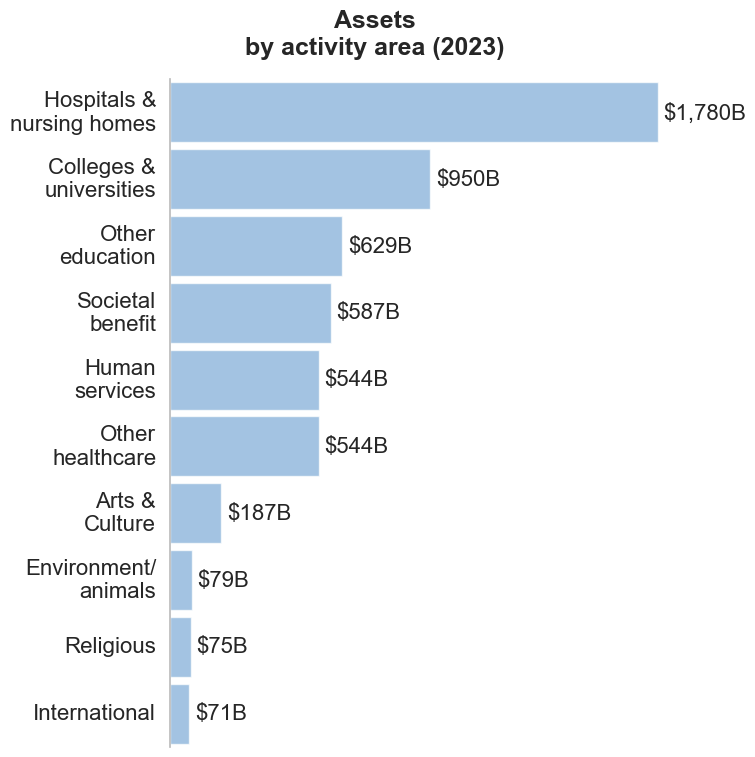

In [36]:
# FIGURE: ASSETS (FOR POSTER)

# ------------------------------------------------------------
# FIGURE SIZE AND PADDING SETTINGS
# ------------------------------------------------------------

fig_width = 8
fig_height = 8

# Padding around the plotting area
left_margin = 0.24       # space for activity-area labels
right_margin = 0.12      # space after longest bar/data label
top_margin = 0.135       # space for title
bottom_margin = 0.03     # space below final activity area

# Distance between end of bar and data label
data_label_offset = 20000000000


# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

plt.rcParams["font.family"] = font_family

fig.patch.set_facecolor("white")
ax.set_facecolor("#FFFFFF")


# ------------------------------------------------------------
# RENAME ACTIVITY AREA DESCRIPTIONS
# ------------------------------------------------------------

activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
    "Mutual/membership": "Mutual &\nmembership",
}


# ------------------------------------------------------------
# CREATE BARPLOT
# ------------------------------------------------------------

sns.barplot(
    data=asset_clean_df,
    x="Assets",
    y="Activity Area",
    # color=network_gray,
    color=rainbow_color_7,
    alpha=0.7,
    dodge=False,
    width=0.9,
    legend=False,
    ax=ax
)


# ------------------------------------------------------------
# CLEAN UP SPINES AND AXES
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spine_color)
ax.spines["bottom"].set_visible(False)

ax.grid(False)

ax.set_xlabel("")
ax.set_ylabel("")


# ------------------------------------------------------------
# FORMAT Y-AXIS LABELS
# ------------------------------------------------------------

y_labels = [
    activity_area_labels.get(
        label.get_text(),
        label.get_text()
    )
    for label in ax.get_yticklabels()
]

ax.set_yticklabels(y_labels)

ax.tick_params(
    axis="y",
    labelsize=bar_poster_axis_labelsize,
    pad=4
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# REMOVE X-AXIS TICKS AND LABELS
# ------------------------------------------------------------

ax.set_xticks([])
ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)


# ------------------------------------------------------------
# ADD DATA LABELS ON BARS
# ------------------------------------------------------------

for p in ax.patches:

    width = p.get_width()

    ax.text(
        width + data_label_offset,
        p.get_y() + p.get_height() / 2,
        f"${width / 1000000000:,.0f}B",
        ha="left",
        va="center",
        fontsize=bar_poster_data_labelsize,
        rotation=0,
    )


# ------------------------------------------------------------
# SET PLOT POSITION
# ------------------------------------------------------------

fig.subplots_adjust(
    left=left_margin,
    right=1 - right_margin,
    top=1 - top_margin,
    bottom=bottom_margin
)


# ------------------------------------------------------------
# ADD TITLE
# ------------------------------------------------------------

ax.set_title(
    "Assets\nby activity area (2023)",
    fontsize=bar_poster_titlesize,
    fontweight="bold",
    pad=18,
    x=0.40
)


# ------------------------------------------------------------
# OUTPUT GRAPH AS SVG
# ------------------------------------------------------------

assets_svg_output_path = os.path.join(
    output_directory,
    assets_file + ".svg"
)

fig.savefig(
    assets_svg_output_path,
    format="svg",
    bbox_inches=None
)

dpi = 300

plt.show()

[5.5 1.4]


C:\Users\hefla\AppData\Local\Temp\ipykernel_31448\1206200397.py:57: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



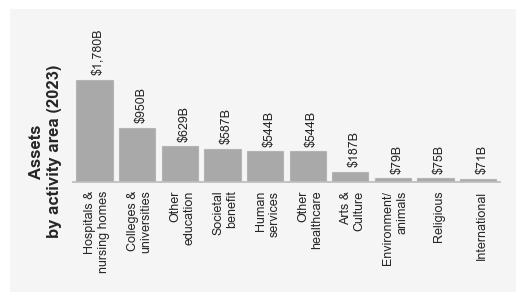

In [37]:
# FIGURE: ASSETS (FOR STATIC COMBO WEB GRAPH)

fig, ax = plt.subplots(figsize=(5.5, 1.4))

plt.rcParams["font.family"] = bar_font_family

fig.patch.set_facecolor("white")
ax.set_facecolor(background_color)

# Rename some of the activity area descriptions to wrap
activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
    "Mutual/membership": "Mutual &\nmembership",
}

# Create barplot
sns.barplot(
    data=asset_clean_df,
    x="Activity Area",
    y="Assets",
    # color=network_blue,
    color=network_gray,
    alpha=0.7,
    dodge=False,
    width=0.9,
    legend=False,
    ax=ax
)

# Clean up spines and axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(spine_color)
ax.grid(False)

ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

x_labels = [
    activity_area_labels.get(
        label.get_text(),
        label.get_text()
    )
    for label in ax.get_xticklabels()
]

ax.set_xticklabels(x_labels)

# Shift labels slightly to the left
label_shift = -0.05

ax.set_xticks(
    np.arange(len(x_labels)) + label_shift,
    labels=x_labels
)

# Format x-axis labels
ax.tick_params(
    axis="x",
    labelsize=bar_axis_labelsize,
    pad=0
)

plt.setp(
    ax.get_xticklabels(),
    rotation=-270,
    ha="right",
    va="top"
)

for label in ax.get_xticklabels():
    label.set_rotation_mode("anchor")

    if "\n" in label.get_text():
        label.set_transform(
            label.get_transform()
            + transforms.ScaledTranslation(
                -6 / 72,
                0,
                fig.dpi_scale_trans
            )
        )

# Add data labels on bars
data_label_padding = 0.1

for p in ax.patches:
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2 + data_label_padding,
        height + 70000000000,
        f"${height / 1000000000:,.0f}B",
        ha="center",
        va="bottom",
        fontsize=bar_axis_labelsize,
        rotation=90,
    )

# Determine label extent
fig.canvas.draw()

renderer = fig.canvas.get_renderer()

label_extents = [
    tick.label1.get_window_extent(renderer)
    for tick in ax.xaxis.get_major_ticks()
]

max_label_height = max(
    ext.height for ext in label_extents
)

# Convert from pixels to figure fraction
fig_height_pixels = fig.bbox.height

pos = ax.get_position()

pad_left = 0.115
pad_right = 0.03
pad_bottom = max_label_height / fig_height_pixels + 0.2
pad_top = 0.46

# Add light-gray panel
panel = Rectangle(
    (
        pos.x0 - pad_left,
        pos.y0 - pad_bottom
    ),
    pos.width + pad_left + pad_right,
    pos.height + pad_top + pad_bottom,
    facecolor=background_color,
    edgecolor="none",
    transform=fig.transFigure,
    zorder=0
)

fig.add_artist(panel)

# Make sure the graph is above the panel
ax.set_zorder(1)

# Add title
pos = ax.get_position()

title_pad = 0.065
fig.text(
    x=panel.get_x() + title_pad,
    y=panel.get_y() + panel.get_height() / 2,
    s="Assets\nby activity area (2023)",
    ha="center",
    va="center",
    fontsize=bar_axis_titlesize,
    fontweight="bold",
    rotation=90,
    zorder=2
)

print(fig.get_size_inches())

save_figure(
    fig,
    assets_sideways_file,
    dpi=300
)

plt.show()

In [38]:
# DATA: REVENUE

# Safety copy of dataframe
revenue_clean_df = revenue_raw_df.copy()

revenue_clean_df["Revenue Adjusted for Inflation"] = revenue_clean_df["Revenue Adjusted for Inflation"].str.replace(",", "").astype("Int64")
revenue_clean_df["Inflation-Adjusted Revenue in Billions"] = revenue_clean_df["Revenue Adjusted for Inflation"] * 1000000000
revenue_clean_df.head()

,Activity Area Original,Activity Area,Year,Revenue Adjusted for Inflation,Inflation-Adjusted Revenue in Billions
0,Hospitals and nursing homes,Hospitals/nursing homes,2006,895,895000000000
1,Hospitals and nursing homes,Hospitals/nursing homes,2009,896,896000000000
2,Hospitals and nursing homes,Hospitals/nursing homes,2015,1239,1239000000000
3,Hospitals and nursing homes,Hospitals/nursing homes,2023,1296,1296000000000
4,Higher Education,Colleges/universities,2006,242,242000000000


C:\Users\hefla\AppData\Local\Temp\ipykernel_31448\1062777599.py:119: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



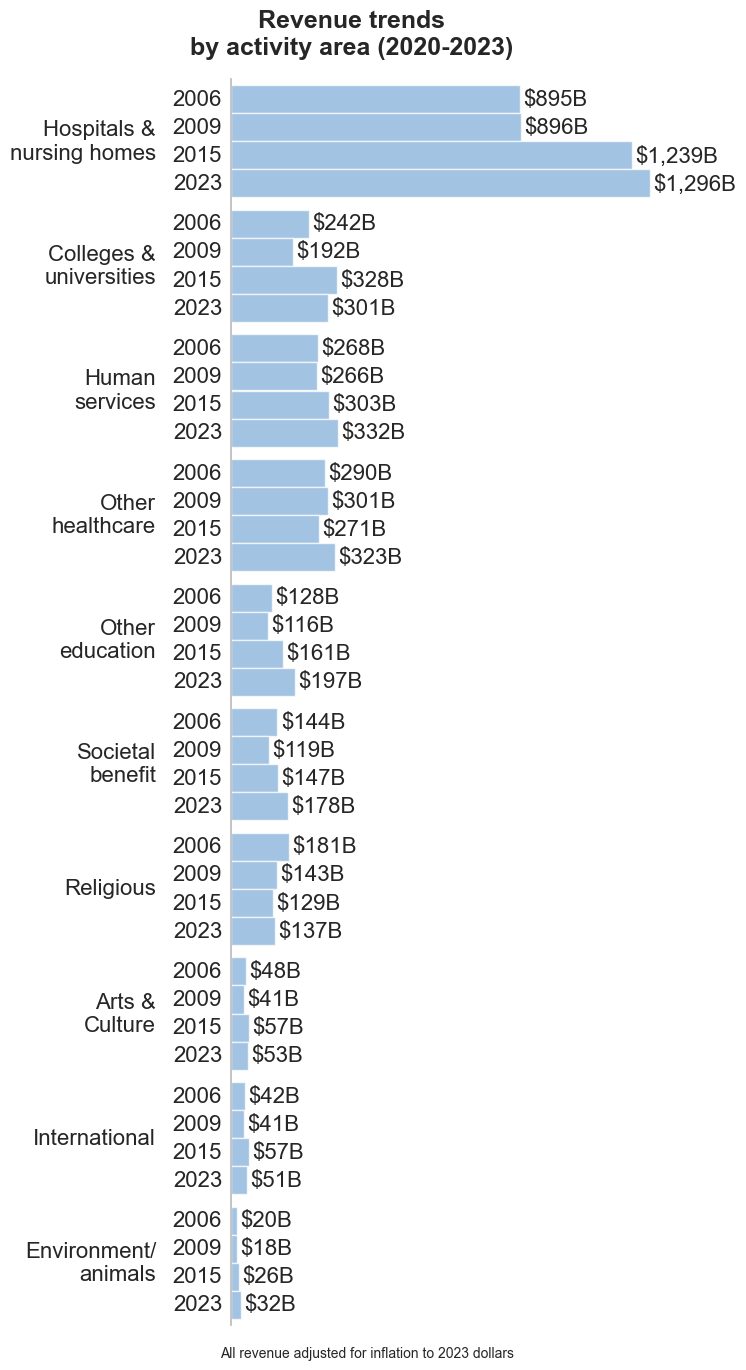

In [39]:
# FIGURE: REVENUE TRENDS (FOR POSTER)

# ------------------------------------------------------------
# FIGURE SIZE AND PADDING SETTINGS
# ------------------------------------------------------------

fig_width = 8
fig_height = 14

# Padding around the plotting area
left_margin = 0.33       # space for activity-area labels
right_margin = 0.12      # space after longest bar/data label
top_margin = 0.075        # space for title
bottom_margin = 0.035     # space for year/activity-area labels

# Distance between end of bar and data label
data_label_offset = 10000000000

# Distance between year labels and activity-area labels
activity_label_pad = 0.17   

# Title horizontal position
title_x = 0.275

# Caption position
caption_y = 0.01


# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

plt.rcParams["font.family"] = font_family

fig.patch.set_facecolor("white")
ax.set_facecolor("#FFFFFF")


# ------------------------------------------------------------
# RENAME ACTIVITY AREA DESCRIPTIONS
# ------------------------------------------------------------

activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
}


# ------------------------------------------------------------
# GET YEARS AND ACTIVITY AREAS
# ------------------------------------------------------------

years = sorted(revenue_clean_df["Year"].unique())

activity_areas = list(
    revenue_clean_df["Activity Area"].unique()
)


# ------------------------------------------------------------
# CREATE BARPLOT
# ------------------------------------------------------------

sns.barplot(
    data=revenue_clean_df,
    x="Inflation-Adjusted Revenue in Billions",
    y="Activity Area",
    hue="Year",
    palette=[
        # network_gray
        rainbow_color_7
    ] * revenue_clean_df["Year"].nunique(),
    alpha=0.7,
    dodge=True,
    width=0.9,
    legend=False,
    ax=ax
)


# ------------------------------------------------------------
# CLEAN UP SPINES AND AXES
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spine_color)
ax.spines["bottom"].set_visible(False)

ax.grid(False)

ax.set_xlabel("")
ax.set_ylabel("")


# ------------------------------------------------------------
# FORMAT Y-AXIS LABELS
# ------------------------------------------------------------

y_labels = [
    activity_area_labels.get(
        label.get_text(),
        label.get_text()
    )
    for label in ax.get_yticklabels()
]

ax.set_yticklabels(y_labels)

ax.tick_params(
    axis="y",
    labelsize=bar_poster_axis_labelsize,
    pad=4
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# REMOVE X-AXIS TICKS AND LABELS
# ------------------------------------------------------------

ax.set_xticks([])

ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)


# ------------------------------------------------------------
# ADD DATA LABELS ON BARS
# ------------------------------------------------------------

for p in ax.patches:

    width = p.get_width()

    ax.text(
        width + data_label_offset,
        p.get_y() + p.get_height() / 2,
        f"${width / 1000000000:,.0f}B",
        ha="left",
        va="center",
        fontsize=bar_poster_data_labelsize,
        rotation=0,
    )


# ------------------------------------------------------------
# SET PLOT POSITION
# ------------------------------------------------------------

fig.subplots_adjust(
    left=left_margin,
    right=1 - right_margin,
    top=1 - top_margin,
    bottom=bottom_margin
)


# ------------------------------------------------------------
# ADD YEAR LABELS NEXT TO EACH BAR
# ------------------------------------------------------------

# Get years in the desired order
years = [2006, 2009, 2015, 2023]

# Get the vertical center of each bar
bar_centers = [
    p.get_y() + p.get_height() / 2
    for p in ax.patches
]

# Sort the bars by their vertical position
# so we can identify the four bars within each
# activity-area group
sorted_centers = sorted(
    enumerate(bar_centers),
    key=lambda x: x[1]
)

# Add the appropriate year to each bar
for group_start in range(0, len(sorted_centers), len(years)):

    group = sorted_centers[
        group_start:group_start + len(years)
    ]

    # Sort the four bars from top to bottom
    group = sorted(
        group,
        key=lambda x: x[1]
    )

    for (_, y), year in zip(group, years):

        ax.text(
            -0.02,
            y,
            str(year),
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=bar_poster_axis_labelsize,
            rotation=0
        )


# ------------------------------------------------------------
# ADD ACTIVITY-AREA LABELS
# ------------------------------------------------------------

# Move the activity-area labels farther left so that the
# year labels sit between them and the bars.

for i, activity_area in enumerate(activity_areas):

    label = activity_area_labels.get(
        activity_area,
        activity_area
    )

    ax.text(
        -activity_label_pad,
        i,
        label,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=bar_poster_axis_labelsize,
    )


# Hide the normal y-axis labels because we have created
# the two-level labels manually.

ax.tick_params(
    axis="y",
    labelleft=False
)


# ------------------------------------------------------------
# ADD TITLE
# ------------------------------------------------------------

ax.set_title(
    "Revenue trends\nby activity area (2020-2023)",
    fontsize=bar_poster_titlesize,
    fontweight="bold",
    pad=18,
    x=title_x
)


# ------------------------------------------------------------
# ADD CAPTION
# ------------------------------------------------------------

fig.text(
    x=0.5,
    y=caption_y,
    s="All revenue adjusted for inflation to 2023 dollars",
    ha="center",
    va="bottom",
    fontsize=bar_poster_caption_size,
)


# ------------------------------------------------------------
# OUTPUT GRAPH AS SVG
# ------------------------------------------------------------

revenue_svg_output_path = os.path.join(
    output_directory,
    revenue_file + ".svg"
)

fig.savefig(
    revenue_svg_output_path,
    format="svg",
    bbox_inches=None
)

dpi = 300

plt.show()


[10.   1.2]


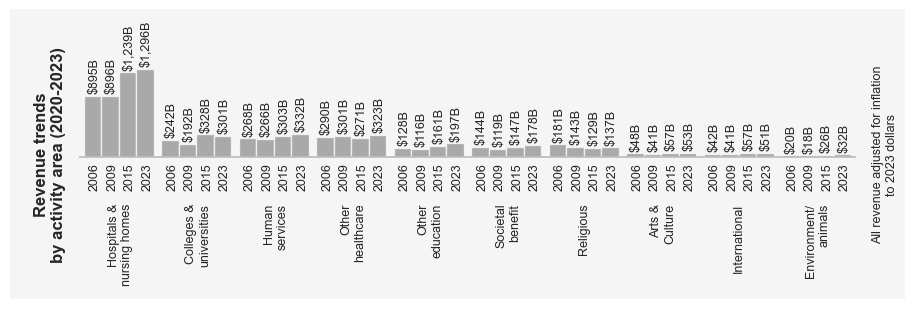

In [40]:
# FIGURE: REVENUE TRENDS (FOR STATIC COMBO WEB GRAPH)

fig, ax = plt.subplots(figsize=(10, 1.2))

plt.rcParams["font.family"] = bar_font_family

fig.patch.set_facecolor("white")
ax.set_facecolor("#F5F5F5")

# Rename some of the activity area descriptions to wrap
activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
}

# Create barplot
sns.barplot(
    data=revenue_clean_df,
    x="Activity Area",
    y="Inflation-Adjusted Revenue in Billions",
    hue="Year",
    # palette=[network_blue] * revenue_clean_df["Year"].nunique(),
    palette=[network_gray] * revenue_clean_df["Year"].nunique(),
    alpha=0.7,
    dodge=True,
    width=0.9,
    legend=False,
    ax=ax
)

# Clean up spines and axes
ax.spines["bottom"].set_color(spine_color)
# ax.spines["bottom"].set_color("lightgray")
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.grid(False)

ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Get years and activity areas in plotting order
years = sorted(revenue_clean_df["Year"].unique())
activity_areas = list(revenue_clean_df["Activity Area"].unique())

# Remove the normal x-axis tick labels
ax.set_xticks([])

# Two-level x-axis labels
 
# Add year labels underneath each individual bar
nudge_year_labels = 0.03
for p, year in zip(ax.patches, np.repeat(years, len(activity_areas))):

    x = p.get_x() + p.get_width() / 2 + nudge_year_labels

    ax.text(
        x,
        -0.06,
        str(year),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add activity-area labels underneath each group of bars
pad_down_from_year_labels = -0.5
for i, activity_area in enumerate(activity_areas):

    label = activity_area_labels.get(
        activity_area,
        activity_area
    )

    if "\n" in label:
        nudge_right = 0.19
    else:
        nudge_right = 0.08

    ax.text(
        i + nudge_right,
        pad_down_from_year_labels,
        label,
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="top",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add data labels on bars
data_label_padding = 0.025
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2 + data_label_padding,
        height + 40000000000,
        f"${height / 1000000000:,.0f}B",
        ha="center",
        va="bottom",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add outlines
fig.canvas.draw()

# Convert from pixels to figure fraction
fig_height_pixels = fig.bbox.height

pos = ax.get_position()
pad_left = 0.07
pad_right = 0.05
pad_bottom = max_label_height / fig_height_pixels + 0.5
pad_top = 0.46

rect = Rectangle(
    (pos.x0 - pad_left, pos.y0 - pad_bottom),
    pos.width + pad_left + pad_right,
    pos.height + pad_top + pad_bottom,
    # fill=False,
    # linewidth=0.75,
    facecolor="#F5F5F5",
    # facecolor="#ffffff",
    edgecolor="none",
    # edgecolor="darkgrey",
    transform=fig.transFigure,
    # zorder=0
)
fig.add_artist(rect)

# Make sure the graph is above the panel
ax.set_zorder(1)

# Add title 

title_pad = 0.04  # distance from left side of rectangle (figure fraction units)
fig.text(
    x=rect.get_x() + title_pad, # a little to the right
    y=rect.get_y() + rect.get_height()/2, # center vertically
    s="Revenue trends\nby activity area (2020-2023)",
    ha="center",
    va="center",
    fontsize=bar_axis_titlesize,
    fontweight="bold",
    rotation=90
)

# Add caption

caption_pad = 0.02

fig.text(
    x=rect.get_x() + rect.get_width() - caption_pad,
    y=rect.get_y() + rect.get_height() / 2,
    s="All revenue adjusted for inflation\nto 2023 dollars",
    ha="center",
    va="center",
    fontsize=bar_axis_labelsize,
    rotation=90
)

# Save figure 

print(fig.get_size_inches())
save_figure(fig, revenue_sideways_file, dpi=300)
plt.show()

In [41]:
assets_img = Image.open(os.path.join(output_directory, assets_sideways_file + ".png"))
revenue_img = Image.open(os.path.join(output_directory, revenue_sideways_file + ".png"))

print("Graph 2:", assets_img.size)
print("Graph 3:", revenue_img.size)

Graph 2: (1524, 853)
Graph 3: (2691, 875)


### <b>Create all-in-one graph from the sankey plus bar charts</b>

In [42]:
# ============================================================
# MASTER HTML: COMBINE ALL THREE FIGURES
# ============================================================

# Paths to the two static figures
assets_image_path = os.path.join(
    output_directory,
    assets_sideways_file + ".png"
)

revenue_image_path = os.path.join(
    output_directory,
    revenue_sideways_file + ".png"
)

# ------------------------------------------------------------
# Read the two PNGs and convert them to base64 so that the
# resulting HTML is completely self-contained.
# ------------------------------------------------------------

import base64

def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

assets_base64 = image_to_base64(assets_image_path)
revenue_base64 = image_to_base64(revenue_image_path)


# ------------------------------------------------------------
# Get the Plotly HTML fragment from Graph 1
# ------------------------------------------------------------

html_fragment = pio.to_html(
    network_fig,
    full_html=False,
    include_plotlyjs=True
)


# ------------------------------------------------------------
# Build the complete HTML document
# ------------------------------------------------------------

full_html = f"""
<html>

<head>

<meta charset="utf-8" />

<style>

html,
body {{
    margin: 0;
    padding: 0;
    background: white;
}}


/* ----------------------------------------------------------
   OUTER CONTAINER

   This is the space occupied by the final rotated figure.
   ---------------------------------------------------------- */

.composite-wrapper {{
    position: relative;

    width: 1500px;
    height: 1500px;

    overflow: visible;
}}


/* ----------------------------------------------------------
   COMPOSITE GRID

   BEFORE rotation:

       ┌────────────────────────────────┐
       │        │                       │
       │ Graph 2│       Graph 3         │
       │        │                       │
       ├────────┴───────────────────────┤
       │                                │
       │             Graph 1            │
       │                                │
       └────────────────────────────────┘

   Then the ENTIRE grid is rotated 90 degrees.
   ---------------------------------------------------------- */

.composite {{
    position: absolute;

    top: 0;
    left: 0;

    width: 1100px;
    height: 1700px;

    display: grid;

    /* grid-template-columns: 345px 455px; */
    /* grid-template-rows: 250px 1100px; */

    grid-template-columns: 800px;
    grid-template-rows: 248px 20px 248px 1130px;

    gap: 0;

    transform: rotate(90deg) translateY(-100%);
    transform-origin: top left;

}}


/* ----------------------------------------------------------
   GRAPH 2
   ---------------------------------------------------------- */

.graph2 {{
    grid-column: 1;
    grid-row: 1;

    position: relative;
    overflow: hidden;

    display: flex;
    align-items: center;
    justify-content: flex-start;

    transform: translateX(25px);
}}

.graph2 img {{
    max-width: 100%;
    max-height: 100%;
    width: auto;
    height: auto;
    object-fit: contain;
}}

/* ----------------------------------------------------------
   GRAPH 3
   ---------------------------------------------------------- */

.graph3 {{
    grid-column: 1;
    /* grid-row: 1; */
    grid-row: 3;

    position: relative;
    overflow: hidden;

    display: flex;
    align-items: center;
    justify-content: flex-start;

    transform: translateX(25px);
}}

.graph3 img {{
    max-width: 100%;
    max-height: 100%;
    width: auto;
    height: auto;
    object-fit: contain;
}}

/* ----------------------------------------------------------
   GRAPH 1
   ---------------------------------------------------------- */

.graph1 {{
    /* grid-column: 1 / 3; */
    /* grid-row: 2; */
    grid-column: 1;
    grid-row: 4;

    position: relative;
    overflow: hidden;

    display: flex;
    justify-content: flex-start;
    align-items: center;

}}

/* ----------------------------------------------------------
   STATIC FIGURES
   ---------------------------------------------------------- */

.static-figure {{
    display: block;

    width: 100%;
    height: 100%;

    object-fit: contain;
}}


/* ----------------------------------------------------------
   CUSTOM PLOTLY TOOLTIP
   ---------------------------------------------------------- */

#custom-tooltip {{
    font-family: {font_family_css};

    font-size: 12px;

    position: fixed;

    display: none;

    background: white;

    border: 1px solid #999;

    padding: 4px;

    pointer-events: none;

    z-index: 9999;

    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
}}

/* ==========================================================
   PRINT / PDF EXPORT
   ========================================================== */

@media print {{

    @page {{
        size: 17in 11in landscape;
        margin: 0;
    }}

    html,
    body {{
        width: 17in;
        height: 11in;
        margin: 0;
        padding: 0;
        overflow: hidden;
        background: white;
    }}

    .composite-wrapper {{
        width: 17in;
        height: 11in;
        position: relative;
        overflow: hidden;
    }}

    .composite {{
        width: 9in;
        height: 11in;

        /* Move the entire composite image down a certain percentage from the top */
        top: 13%;
        left: 0px;

        transform: rotate(90deg) translateY(-150.5%) scale(0.96);
        transform-origin: top left;

        margin-top: 0;
    }}

    /* Don't let the browser add any surprises */
    * {{
        -webkit-print-color-adjust: exact !important;
        print-color-adjust: exact !important;
    }}

}}

</style>

</head>


<body>


<div class="composite-wrapper">

    <div class="composite">


        <!-- ================================================
             GRAPH 2 — ASSETS
             ================================================ -->

        <div class="graph2">

            <img
                class="static-figure"
                src="data:image/png;base64,{assets_base64}"
            >

        </div>


        <!-- ================================================
             GRAPH 3 — REVENUE
             ================================================ -->

        <div class="graph3">

            <img
                class="static-figure"
                src="data:image/png;base64,{revenue_base64}"
            >

        </div>


        <!-- ================================================
             GRAPH 1 — SANKEY
             ================================================ -->

        <div class="graph1">

            {html_fragment}

        </div>


    </div>

</div>


<!-- Plotly custom tooltip -->

<div id="custom-tooltip"></div>


<script>

window.addEventListener("load", function() {{

    const tooltip =
        document.getElementById("custom-tooltip");

    const plotDiv =
        document.querySelector(".plotly-graph-div");

    if (!plotDiv) return;


    plotDiv.on("plotly_hover", function(eventData) {{

        const point = eventData.points[0];

        const e = eventData.event;

        tooltip.innerHTML = point.customdata;

        tooltip.style.display = "block";


        tooltip.style.left =
            (e.pageX + 15) + "px";

        tooltip.style.top =
            (e.pageY + 15) + "px";

    }});


    plotDiv.on("plotly_unhover", function() {{

        tooltip.style.display = "none";

    }});

}});

</script>


</body>

</html>
"""


# ------------------------------------------------------------
# Write the combined HTML file
# ------------------------------------------------------------

combo_output_path = os.path.join(output_directory, sankey_web_static_with_bars_file + ".html")
with open(combo_output_path, "w", encoding="utf-8") as f:
    f.write(full_html)
print(f"Combined figure written to: {combo_output_path}")

Combined figure written to: ..\figures\USINE_sankey_static_with_bars.html


### <b>Create intermediary graphs</b>

In [43]:
# Set data types
im_clean_df = im_raw_df.copy()

im_clean_df["990 Value"] = im_clean_df["990 Value"].astype("Int64")
im_clean_df["Year"] = im_clean_df["Year"].astype("Int64")

# Limit to 2020-2023
im_clean_df = im_clean_df[im_clean_df["Year"] != 2024]

In [44]:
im_clean_df["Intermediary"].value_counts(0)

Intermediary
Private foundations    12
Donor-advised funds    12
Name: count, dtype: int64

In [45]:
# Split into PF and DAF data sets

pf_df = im_clean_df[im_clean_df["Intermediary"] == "Private foundations"]
daf_df = im_clean_df[im_clean_df["Intermediary"] == "Donor-advised funds"]

print(pf_df.shape)
print(daf_df.shape)

# pf_df.head()
daf_df.head()

(12, 5)
(12, 5)


,Intermediary,Metric,Year,990 Value,Other Value
15,Donor-advised funds,Assets,2020,152419755653,NaN
16,Donor-advised funds,Assets,2021,239529821421,NaN
17,Donor-advised funds,Assets,2022,235260614722,NaN
18,Donor-advised funds,Assets,2023,253704215326,NaN
20,Donor-advised funds,Contributions,2020,46527557413,NaN


In [46]:
# Pivot the data sets

# Pull records
# flipflop_df = c4_figures_clean_df.loc[
#     c4_figures_clean_df["Figure"] == c4_figure,
#     ["Figure", "Year", "Breakdown_1", "Value"]
# ]

# Rename columns
# flipflop_df.rename(
#     columns={
#         "Breakdown_1": "Metric",
#         "Value": "Std Dev from Annual Average"
#     },
#     inplace=True
# )

# Pivot to wide format for line graph
pf_wide_df = pf_df.pivot(
    index="Year",
    columns="Metric",
    values="990 Value"
).fillna(0)

# Pivot to wide format for line graph
daf_wide_df = daf_df.pivot(
    index="Year",
    columns="Metric",
    values="990 Value"
).fillna(0)

print(pf_wide_df.shape)
print(daf_wide_df.shape)
# print(pf_wide_df.head())
print(daf_wide_df.head())

(4, 3)
(4, 3)
Metric        Assets  Contributions       Grants
Year                                            
2020    152419755653    46527557413  33212812983
2021    239529821421    85405510312  47253537644
2022    235260614722    75236492213  53275742238
2023    253704215326    63891111399  53643449776


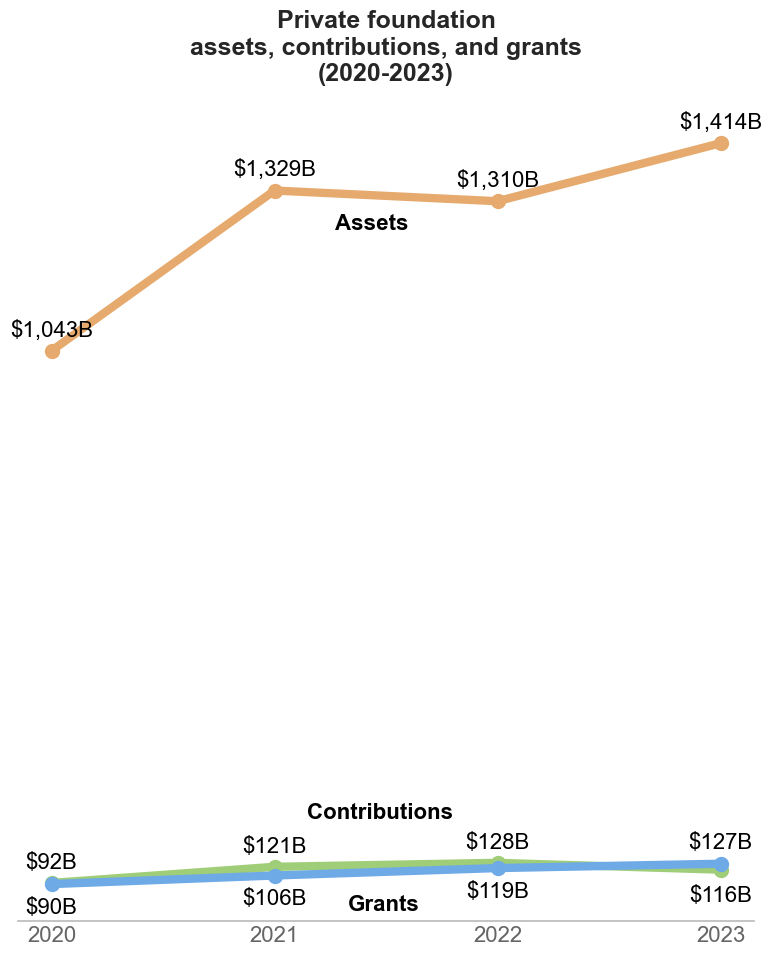

In [47]:
# FIGURE: PF C-G-A (FOR POSTER)

# ------------------------------------------------------------
# FIGURE SIZE AND PADDING SETTINGS
# ------------------------------------------------------------

fig_width = 8
fig_height = 10

# Padding around the plotting area
left_margin = 0.04       # space before first year
right_margin = 0.04      # space after final year / line labels
top_margin = 0.135       # space for title
bottom_margin = 0.05     # space below x-axis labels


# ------------------------------------------------------------
# DATA LABEL SETTINGS
# ------------------------------------------------------------

assets_data_label_y_offset = 18_500_000_000
contribs_data_label_y_offset = 18_500_000_000

grants_data_label_x_offset = 0
grants_data_label_y_offset = -60_000_000_000


# ------------------------------------------------------------
# LINE LABEL SETTINGS
# ------------------------------------------------------------

x_assets_label_offset = 0.6
y_assets_label_offset = -40_000_000_000

x_contributions_label_offset = 0.8
y_contributions_label_offset = 90_000_000_000

x_grants_label_offset = 0.65
y_grants_label_offset = -65_000_000_000


# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

pf_fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

graph_df = pf_wide_df.copy()

plt.rcParams["font.family"] = font_family

pf_fig.patch.set_facecolor("white")
ax.set_facecolor("#FFFFFF")


# ------------------------------------------------------------
# SET METRICS
# ------------------------------------------------------------

years = graph_df.index.astype(int)

assets = graph_df.iloc[:, 0]
contributions = graph_df.iloc[:, 1]
grants = graph_df.iloc[:, 2]

metric_names = graph_df.columns

metric_name_1 = "Assets"
metric_name_2 = "Contributions"
metric_name_3 = "Grants"


# ------------------------------------------------------------
# LINE FORMATTING
# ------------------------------------------------------------

marker_size = 10
line_width = 6


# ------------------------------------------------------------
# PLOT LINES
# ------------------------------------------------------------

ax.plot(
    years,
    graph_df[metric_names[0]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_3,
    label=graph_df.columns[0]
)

ax.plot(
    years,
    graph_df[metric_names[1]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_5,
    label=graph_df.columns[1]
)

ax.plot(
    years,
    graph_df[metric_names[2]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_7,
    label=graph_df.columns[2]
)


# ------------------------------------------------------------
# CLEAN UP SPINES AND AXES
# ------------------------------------------------------------

# Keep the x-axis as the visible axis
ax.spines["bottom"].set_color(spine_color)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(False)

ax.set_xlabel("")
ax.set_ylabel("")


# ------------------------------------------------------------
# FORMAT X-AXIS
# ------------------------------------------------------------

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_yticks([])

ax.tick_params(
    axis="x",
    labelsize=im_poster_axis_labelsize,
    length=0,
    colors=node_outline_color,
)

ax.tick_params(
    axis="y",
    labelsize=im_poster_axis_labelsize,
    colors=node_outline_color,
    length=0
)


# ------------------------------------------------------------
# ADD DATA LABELS
# ------------------------------------------------------------

for x, y in zip(years, assets):

    label = f"${y / 1000000000:,.0f}B"

    ax.text(
        x,
        y + assets_data_label_y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        color="black"
    )


for x, y in zip(years, contributions):

    label = f"${y / 1000000000:,.0f}B"

    if x == years[-1]:
        y_offset = -65_000_000_000
    else:
        y_offset = contribs_data_label_y_offset

    ax.text(
        x,
        y + y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        color="black"
    )


for x, y in zip(years, grants):

    label = f"${y / 1000000000:,.0f}B"

    if x == years[-1]:
        y_offset = 20_000_000_000
    else:
        y_offset = grants_data_label_y_offset

    ax.text(
        x + grants_data_label_x_offset,
        y + y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        color="black"
    )


# ------------------------------------------------------------
# ADD LINE LABEL: ASSETS
# ------------------------------------------------------------

x_assets_label = years[-3]
y_assets_label = assets.iloc[-2]

ax.text(
    x_assets_label + x_assets_label_offset,
    y_assets_label + y_assets_label_offset,
    metric_name_1,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# ADD LINE LABEL: CONTRIBUTIONS
# ------------------------------------------------------------

x_contributions_label = years[-3]
y_contributions_label = contributions.iloc[-2]

ax.text(
    x_contributions_label + x_contributions_label_offset,
    y_contributions_label + y_contributions_label_offset,
    metric_name_2,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# ADD LINE LABEL: GRANTS
# ------------------------------------------------------------

x_grants_label = years[-3]
y_grants_label = grants.iloc[-2]

ax.text(
    x_grants_label + x_grants_label_offset,
    y_grants_label + y_grants_label_offset,
    metric_name_3,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# SET PLOT POSITION
# ------------------------------------------------------------

pf_fig.subplots_adjust(
    left=left_margin,
    right=1 - right_margin,
    top=1 - top_margin,
    bottom=bottom_margin
)


# ------------------------------------------------------------
# ADD TITLE
# ------------------------------------------------------------

ax.set_title(
    "Private foundation\nassets, contributions, and grants\n(2020-2023)",
    fontsize=im_poster_titlesize,
    fontweight="bold",
    pad=18,
    x=0.50
)


# ------------------------------------------------------------
# OUTPUT GRAPH AS SVG
# ------------------------------------------------------------

pf_svg_output_path = os.path.join(
    output_directory,
    pf_file + ".svg"
)

pf_fig.savefig(
    pf_svg_output_path,
    format="svg",
    bbox_inches=None
)

dpi = 300

plt.show()

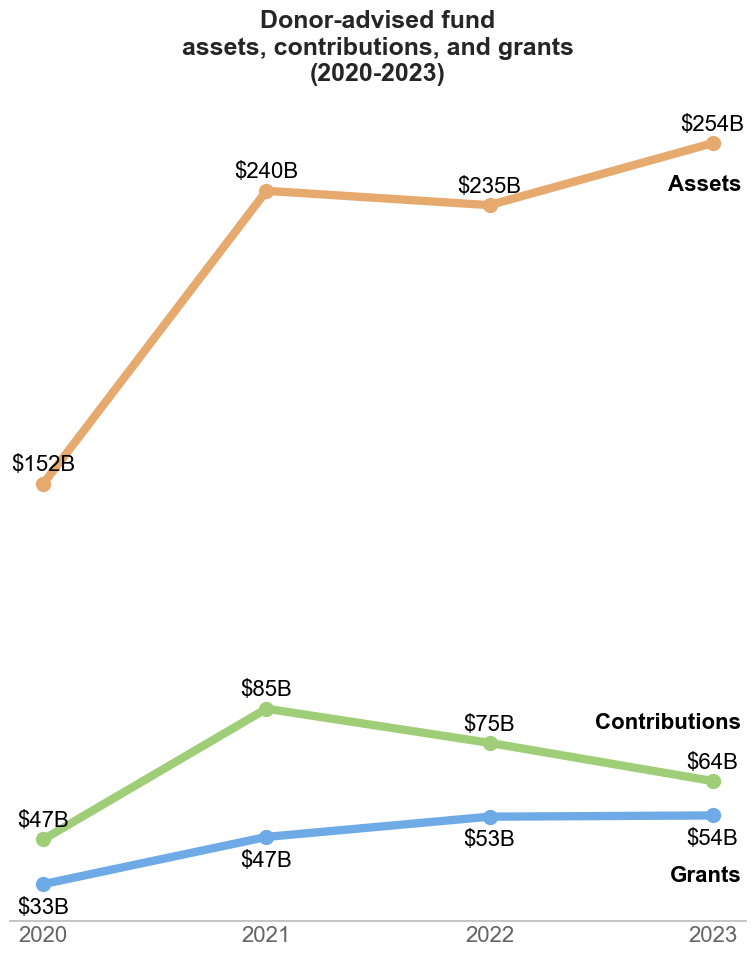

In [48]:
# FIGURE: DAF C-G-A (FOR POSTER)

# ------------------------------------------------------------
# FIGURE SIZE AND PADDING SETTINGS
# ------------------------------------------------------------

fig_width = 8
fig_height = 10

# Padding around the plotting area
left_margin = 0.04       # space before first year
right_margin = 0.04      # space after final year / line labels
top_margin = 0.135        # space for title
bottom_margin = 0.05     # space below x-axis labels


# ------------------------------------------------------------
# DATA LABEL SETTINGS
# ------------------------------------------------------------

# assets_data_label_y_offset = 10_000_000_000
assets_data_label_y_offset = 2_500_000_000
# contribs_data_label_y_offset = 10_000_000_000
contribs_data_label_y_offset = 2_500_000_000

# grants_data_label_x_offset = 0.25
grants_data_label_x_offset = 0
# grants_data_label_y_offset = -12_000_000_000
grants_data_label_y_offset = -10_000_000_000


# ------------------------------------------------------------
# LINE LABEL SETTINGS
# ------------------------------------------------------------

# x_assets_label_offset = 0.20
x_assets_label_offset = 0.13
# y_assets_label_offset = 25_000_000_000
y_assets_label_offset = 6_000_000_000

# x_contributions_label_offset = 0.57
x_contributions_label_offset = 0.13
# y_contributions_label_offset = 42_000_000_000
y_contributions_label_offset = 6_000_000_000

# x_grants_label_offset = 0.16
x_grants_label_offset = 0.13
# y_grants_label_offset = -15_500_000_000
y_grants_label_offset = -17_500_000_000


# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

daf_fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

graph_df = daf_wide_df.copy()

plt.rcParams["font.family"] = font_family

daf_fig.patch.set_facecolor("white")
ax.set_facecolor("#FFFFFF")


# ------------------------------------------------------------
# SET METRICS
# ------------------------------------------------------------

years = graph_df.index.astype(int)

assets = graph_df.iloc[:, 0]
contributions = graph_df.iloc[:, 1]
grants = graph_df.iloc[:, 2]

metric_names = graph_df.columns

metric_name_1 = "Assets"
metric_name_2 = "Contributions"
metric_name_3 = "Grants"


# ------------------------------------------------------------
# LINE FORMATTING
# ------------------------------------------------------------

marker_size = 10
line_width = 6


# ------------------------------------------------------------
# PLOT LINES
# ------------------------------------------------------------

ax.plot(
    years,
    graph_df[metric_names[0]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_3,
    label=graph_df.columns[0]
)

ax.plot(
    years,
    graph_df[metric_names[1]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_5,
    label=graph_df.columns[1]
)

ax.plot(
    years,
    graph_df[metric_names[2]],
    linewidth=line_width,
    marker="o",
    markersize=marker_size,
    color=rainbow_color_7,
    label=graph_df.columns[2]
)


# ------------------------------------------------------------
# CLEAN UP SPINES AND AXES
# ------------------------------------------------------------

# Keep the x-axis as the visible axis
ax.spines["bottom"].set_color(spine_color)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(False)

ax.set_xlabel("")
ax.set_ylabel("")


# ------------------------------------------------------------
# FORMAT X-AXIS
# ------------------------------------------------------------

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_yticks([])

ax.tick_params(
    axis="x",
    labelsize=im_poster_axis_labelsize,
    length=0,
    # colors="#bbbbbb"
    colors=node_outline_color
)

ax.tick_params(
    axis="y",
    labelsize=im_poster_axis_labelsize,
    # colors="#bbbbbb",
    colors=node_outline_color,
    length=0
)


# ------------------------------------------------------------
# ADD DATA LABELS
# ------------------------------------------------------------

for x, y in zip(years, assets):

    label = f"${y / 1000000000:,.0f}B"

    ax.text(
        x,
        y + assets_data_label_y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        # color=node_outline_color
        color="black"
    )


for x, y in zip(years, contributions):

    label = f"${y / 1000000000:,.0f}B"

    ax.text(
        x,
        y + contribs_data_label_y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        # color=node_outline_color
        color="black"
    )


for x, y in zip(years, grants):

    label = f"${y / 1000000000:,.0f}B"

    ax.text(
        x + grants_data_label_x_offset,
        y + grants_data_label_y_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=im_poster_data_labelsize,
        # color=node_outline_color
        color="black"
    )


# ------------------------------------------------------------
# ADD LINE LABEL: ASSETS
# ------------------------------------------------------------

x_assets_label = years[-1]
y_assets_label = assets.iloc[-2]

ax.text(
    x_assets_label + x_assets_label_offset,
    y_assets_label + y_assets_label_offset,
    metric_name_1,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# ADD LINE LABEL: CONTRIBUTIONS
# ------------------------------------------------------------

x_contributions_label = years[-1]
y_contributions_label = contributions.iloc[-2]

ax.text(
    x_contributions_label + x_contributions_label_offset,
    y_contributions_label + y_contributions_label_offset,
    metric_name_2,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# ADD LINE LABEL: GRANTS
# ------------------------------------------------------------

x_grants_label = years[-1]
y_grants_label = grants.iloc[-2]

ax.text(
    x_grants_label + x_grants_label_offset,
    y_grants_label + y_grants_label_offset,
    metric_name_3,
    color="black",
    fontsize=im_poster_data_labelsize,
    fontweight="bold",
    ha="right",
    va="center"
)


# ------------------------------------------------------------
# SET PLOT POSITION
# ------------------------------------------------------------

daf_fig.subplots_adjust(
    left=left_margin,
    right=1 - right_margin,
    top=1 - top_margin,
    bottom=bottom_margin
)


# ------------------------------------------------------------
# ADD TITLE
# ------------------------------------------------------------

ax.set_title(
    "Donor-advised fund\nassets, contributions, and grants\n(2020-2023)",
    fontsize=im_poster_titlesize,
    fontweight="bold",
    pad=18,
    x=0.50
)


# ------------------------------------------------------------
# OUTPUT GRAPH AS SVG
# ------------------------------------------------------------

daf_svg_output_path = os.path.join(
    output_directory,
    daf_file + ".svg"
)

daf_fig.savefig(
    daf_svg_output_path,
    format="svg",
    bbox_inches=None
)

dpi = 300

plt.show()

### <b>More Sankey label tests</b>

In [51]:
# SANKEY - BIG VERSION FOR POSTER (SVG OUTPUT)

# Poster figure dimensions
plotly_width_inches = 11
plotly_height_inches = 15
px_per_inch = 96
plotly_width = int(plotly_width_inches * px_per_inch)
plotly_height = int(plotly_height_inches * px_per_inch)

label_position_by_index = {
    0: 0.77,  # gray
    1: 0.62,  # pink
    2: 0.52,  # orange
    3: 0.42,  # yellow
    4: 0.37,  # green
    5: 0.32,  # teal
    6: 0.30,  # blue
    7: 0.25,  # purple
}

label_position_special = {
    "Donor-advised fund sponsors": 0.60,
    "Foundations (minus community foundation DAF sponsors)": 0.60,
}

flow_label_adjustments = {
    ("Donor-advised fund sponsors", "Hospitals and nursing homes"): (0.0070, 0.0000),
    ("Donor-advised fund sponsors", "Health (minus hospitals and nursing homes)"): (0.0070, -0.0090),
    ("Donor-advised fund sponsors", "Human Services"): (0.0070, -0.0140),
    ("Donor-advised fund sponsors", "Colleges and universities"): (0.0120, -0.0250),
    ("Donor-advised fund sponsors", "Education (minus colleges and universities)"): (0.0170, -0.0400),
    ("Donor-advised fund sponsors", "Public/societal benefit (minus national DAF sponsors)"): (0.0220, -0.0550),
    ("Donor-advised fund sponsors", "Religious congregations"): (0.0270, -0.0500),
    ("Donor-advised fund sponsors", "International/foreign affairs"): (0.0320, -0.0420),
    ("Donor-advised fund sponsors", "Arts, culture, humanities"): (0.0370, -0.0350),
    ("Donor-advised fund sponsors", "Environment and animals"): (0.0420, -0.0200),
    # ("Donor-advised fund sponsors", "Donor-advised fund sponsors (ghost)"): (0.0000, 0.0000),
    ("Donor-advised fund sponsors (ghost)", "Donor-advised fund sponsors"): (-0.0330, 0.0120),
    ("Foundations (minus community foundation DAF sponsors)", "Hospitals and nursing homes"): (-0.0500, 0.1800),
    ("Foundations (minus community foundation DAF sponsors)", "Health (minus hospitals and nursing homes)"): (-0.0400, 0.1350),
    ("Foundations (minus community foundation DAF sponsors)", "Human Services"): (-0.0300, 0.0900),
    ("Foundations (minus community foundation DAF sponsors)", "Colleges and universities"): (-0.0200, 0.0550),
    ("Foundations (minus community foundation DAF sponsors)", "Education (minus colleges and universities)"): (-0.0100, 0.0300),
    ("Foundations (minus community foundation DAF sponsors)", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, 0.0050),
    ("Foundations (minus community foundation DAF sponsors)", "Religious congregations"): (0.0100, 0.0000),
    ("Foundations (minus community foundation DAF sponsors)", "International/foreign affairs"): (0.0200, -0.0100),
    ("Foundations (minus community foundation DAF sponsors)", "Arts, culture, humanities"): (0.0300, -0.0100),
    ("Foundations (minus community foundation DAF sponsors)", "Environment and animals"): (0.0400, -0.0050),
    # ("Foundations (minus community foundation DAF sponsors)", "Foundations (minus community foundation DAF sponsors) (ghost)"): (0.0000, 0.0000),
    ("Foundations (minus community foundation DAF sponsors) (ghost)", "Foundations (minus community foundation DAF sponsors)"): (-0.03400, 0.0350),
    ("Foundations (minus community foundation DAF sponsors)", "Donor-advised fund sponsors"): (-0.0500, -0.0100),
    ("Individuals", "Hospitals and nursing homes"): (-0.0650, 0.0350),
    ("Individuals", "Health (minus hospitals and nursing homes)"): (-0.0520, 0.0250),
    ("Individuals", "Human Services"): (-0.0390, 0.0150),
    ("Individuals", "Colleges and universities"): (-0.0260, 0.0080),
    ("Individuals", "Education (minus colleges and universities)"): (-0.0130, 0.0000),
    ("Individuals", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, 0.0000),
    ("Individuals", "Religious congregations"): (0.0130, 0.0000),
    ("Individuals", "International/foreign affairs"): (0.0260, 0.0000),
    ("Individuals", "Arts, culture, humanities"): (0.0390, 0.0050),
    ("Individuals", "Environment and animals"): (0.0520, 0.0160),
    ("Individuals", "Unknown, unclassified"): (0.0650, 0.0300),
    ("Individuals", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0150),
    ("Individuals", "Donor-advised fund sponsors"): (0.0300, 0.0250),
    ("Bequests", "Hospitals and nursing homes"): (-0.0900, 0.0750),
    ("Bequests", "Health (minus hospitals and nursing homes)"): (-0.0750, 0.0550),
    ("Bequests", "Human Services"): (-0.0600, 0.0400),
    ("Bequests", "Colleges and universities"): (-0.0450, 0.0250),
    ("Bequests", "Education (minus colleges and universities)"): (-0.0300, 0.0100),
    ("Bequests", "Public/societal benefit (minus national DAF sponsors)"): (-0.0150, 0.0030),
    ("Bequests", "Religious congregations"): (0.0000, -0.0050),
    ("Bequests", "International/foreign affairs"): (0.0150, 0.0000),
    ("Bequests", "Arts, culture, humanities"): (0.0300, 0.0070),
    ("Bequests", "Environment and animals"): (0.0450, 0.0200),
    ("Bequests", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
    ("Corporations", "Hospitals and nursing homes"): (-0.0600, 0.0530),
    ("Corporations", "Health (minus hospitals and nursing homes)"): (-0.0450, 0.0350),
    ("Corporations", "Human Services"): (-0.0300, 0.0180),
    ("Corporations", "Colleges and universities"): (-0.0150, 0.0080),
    ("Corporations", "Education (minus colleges and universities)"): (-0.0000, 0.0000),
    ("Corporations", "Public/societal benefit (minus national DAF sponsors)"): (0.0150, -0.0050),
    ("Corporations", "Religious congregations"): (0.0300, 0.0000),
    ("Corporations", "International/foreign affairs"): (0.0450, 0.0100),
    ("Corporations", "Arts, culture, humanities"): (0.0600, 0.0300),
    ("Corporations", "Environment and animals"): (0.0750, 0.0500),
    ("Corporations", "Foundations (minus community foundation DAF sponsors)"): (-0.0100, -0.0200),
    ("State and local government", "Hospitals and nursing homes"): (-0.1200, 0.0850),
    ("State and local government", "Health (minus hospitals and nursing homes)"): (-0.1000, 0.0450),
    ("State and local government", "Human Services"): (-0.0800, 0.0200),
    ("State and local government", "Colleges and universities"): (-0.0600, 0.0020),
    ("State and local government", "Education (minus colleges and universities)"): (-0.0400, -0.0100),
    ("State and local government", "Public/societal benefit (minus national DAF sponsors)"): (-0.0200, -0.0100),
    ("State and local government", "Religious congregations"): (0.0000, 0.0000),
    ("State and local government", "Arts, culture, humanities"): (0.0200, 0.0200),
    ("State and local government", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
    ("Federal government", "Hospitals and nursing homes"): (-0.0600, 0.0500),
    ("Federal government", "Health (minus hospitals and nursing homes)"): (-0.0500, 0.0110),
    ("Federal government", "Human Services"): (-0.0400, 0.0000),
    ("Federal government", "Colleges and universities"): (-0.0300, -0.0050),
    ("Federal government", "Education (minus colleges and universities)"): (-0.0200, -0.0100),
    ("Federal government", "Public/societal benefit (minus national DAF sponsors)"): (-0.0100, -0.0050),
    ("Federal government", "Religious congregations"): (0.0000, -0.0050),
    ("Federal government", "International/foreign affairs"): (0.0100, 0.0100),
    ("Federal government", "Arts, culture, humanities"): (0.0200, 0.0160),
    ("Federal government", "Unknown, unclassified"): (0.0400, 0.0500),
    ("Federal government", "Foundations (minus community foundation DAF sponsors)"): (0.0030, 0.0100),
    ("Program fees from private sources", "Hospitals and nursing homes"): (-0.0500, -0.0040),
    ("Program fees from private sources", "Health (minus hospitals and nursing homes)"): (-0.0400, -0.0000),
    ("Program fees from private sources", "Human Services"): (-0.0300, -0.0060),
    ("Program fees from private sources", "Colleges and universities"): (-0.0200, -0.0050),
    ("Program fees from private sources", "Education (minus colleges and universities)"): (-0.0100, -0.0010),
    ("Program fees from private sources", "Public/societal benefit (minus national DAF sponsors)"): (0.0000, -0.0010),
    ("Program fees from private sources", "Religious congregations"): (0.0100, 0.0020),
    ("Program fees from private sources", "International/foreign affairs"): (0.0200, 0.0100),
    ("Program fees from private sources", "Arts, culture, humanities"): (0.0300, 0.0200),
    ("Program fees from private sources", "Environment and animals"): (0.0400, 0.0300),
    ("Program fees from private sources", "Unknown, unclassified"): (0.0500, 0.0450),
    ("Program fees from private sources", "Foundations (minus community foundation DAF sponsors)"): (-0.0050, -0.0160),
    ("Investment Income", "Hospitals and nursing homes"): (-0.0400, 0.0400),
    ("Investment Income", "Health (minus hospitals and nursing homes)"): (-0.0250, 0.0200),
    ("Investment Income", "Human Services"): (-0.0100, 0.0060),
    ("Investment Income", "Colleges and universities"): (0.0050, 0.0000),
    ("Investment Income", "Education (minus colleges and universities)"): (0.0200, -0.0050),
    ("Investment Income", "Public/societal benefit (minus national DAF sponsors)"): (0.0350, 0.0000),
    ("Investment Income", "Arts, culture, humanities"): (0.0550, 0.0370),
    ("Investment Income", "Foundations (minus community foundation DAF sponsors)"): (0.0000, 0.0000),
}

# For fixed-threshold data labels
flow_label_threshold = 1

poster_fig = go.Figure(go.Sankey(
    arrangement="snap",
    
    node=dict(
        # label=node_format_df["Node"],
        label=[""] * len(node_format_df), # remove default labels
        x=node_format_df["X"],
        y=node_format_df["Y"],
        pad=15,
        thickness=18,
        line=dict(color=to_rgba("#454545", alpha=0.5), width=0.25),
        # line=dict(color="rgba(0,0,0,0)", width=0),
        color=node_colors,
        hoverinfo="skip"
    ),
    
    link=dict(
        # arrowlen=10,
        source=sources,
        target=targets,
        value=values,
        color=edge_colors,
        # customdata=hover_text,
        hoverinfo="none"
        # hovertemplate="%{customdata}<extra></extra>"
    )
))

# Define annotations for labels
annotations = []

for _, row in node_format_df[node_format_df["Node Type"] == "Source"].iterrows():
    node_name = row[node_id_field]
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="center",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Recipient"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="center",
        textangle=-90
    ))
for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Left"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field].replace("$", "&#36;"),
        showarrow=False,
        xanchor="left",
        align="left",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Right"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field].replace("$", "&#36;"),
        showarrow=False,
        xanchor="right",
        align="right",
        textangle=-90
    ))

print("Number of flows:", len(values))
print("Largest flow:", max(values))
print("Flows >= threshold:", sum(values >= flow_label_threshold))
print("Threshold:", flow_label_threshold)

# ------------------------------------------------------------
# ADD FLOW LABELS - COLLISION-AWARE POSITIONING
# ------------------------------------------------------------

# How close two labels have to be before we consider them
# potential collisions.
label_x_threshold = 0.02
label_y_threshold = 0.02

# Minimum separation between labels that are in the same
# collision group.
label_separation = 0.2

# Maximum amount a label can be moved away from its natural
# position along the flow.
max_jitter = 0.0


# ------------------------------------------------------------
# FIRST PASS: CALCULATE NATURAL LABEL POSITIONS
# ------------------------------------------------------------

flow_labels = []

for source, target, value, edge_color in zip(sources, targets, values, edge_colors):

    source_node = node_format_df.iloc[source][node_id_field]
    target_node = node_format_df.iloc[target][node_id_field]

    if (
        value >= flow_label_threshold
        # and "ghost" not in source_node
        and "ghost" not in target_node
    ):
        
        source_x = node_format_df.iloc[source]["X"]
        source_y = node_format_df.iloc[source]["Y"]

        target_x = node_format_df.iloc[target]["X"]
        target_y = node_format_df.iloc[target]["Y"]

        # Get label position from the source node
        label_position = get_label_position(source_node)

        source_annotation_y = 1 - source_y
        target_annotation_y = 1 - target_y

        # ----------------------------------------------------
        # APPROXIMATE THE CURVED SANKEY FLOW
        # ----------------------------------------------------

        # Start and end points
        p0 = (
            source_x,
            source_annotation_y
        )

        p3 = (
            target_x,
            target_annotation_y
        )

        # Horizontal control points.
        #
        # Sankey flows generally leave the source horizontally,
        # curve through the middle, and approach the target
        # horizontally.
        #
        # The control-point distance controls how strongly
        # curved the approximation is.

        curve_strength = 0.55

        horizontal_distance = target_x - source_x

        p1 = (
            source_x + curve_strength * horizontal_distance,
            source_annotation_y
        )

        p2 = (
            target_x - curve_strength * horizontal_distance,
            target_annotation_y
        )

        # ----------------------------------------------------
        # LABEL POSITION ALONG THE CURVE
        # ----------------------------------------------------

        t = label_position

        natural_x, natural_y = bezier_point(
            p0, p1, p2, p3, t
        )

        # Get any manual adjustment for this specific flow
        x_offset, y_offset = flow_label_adjustments.get(
            (source_node, target_node),
            (0, 0)
        )

        # ----------------------------------------------------
        # DIRECTION OF THE CURVE AT THE LABEL
        # ----------------------------------------------------

        dx, dy = bezier_tangent(
            p0, p1, p2, p3, t
        )

        flow_length = (dx**2 + dy**2)**0.5

        if flow_length == 0:

            perpendicular_x = 0
            perpendicular_y = 1

        else:

            # Unit vector perpendicular to the actual
            # curved flow at the label's location.
            perpendicular_x = -dy / flow_length
            perpendicular_y = dx / flow_length

        # ----------------------------------------------------
        # FLOW DIRECTION
        # ----------------------------------------------------

        # IMPORTANT:
        # Annotation coordinates use 1 - Y, so convert the
        # Sankey Y coordinates into the annotation coordinate
        # system before calculating the flow direction.

        source_annotation_y = 1 - source_y
        target_annotation_y = 1 - target_y

        dx = target_x - source_x
        dy = target_annotation_y - source_annotation_y

        flow_length = (dx**2 + dy**2)**0.5

        if flow_length == 0:

            perpendicular_x = 0
            perpendicular_y = 1

        else:

            # Unit vector perpendicular to the flow
            perpendicular_x = -dy / flow_length
            perpendicular_y = dx / flow_length

        flow_labels.append({
            "source": source,
            "target": target,
            "value": value,
            "edge_color": edge_color,
            # "midpoint_x": midpoint_x,
            # "midpoint_y": midpoint_y,
            "natural_x": natural_x,
            "natural_y": natural_y,
            "x_offset": x_offset,
            "y_offset": y_offset,
            "perpendicular_x": perpendicular_x,
            "perpendicular_y": perpendicular_y,
            "jitter": 0
        })


# ------------------------------------------------------------
# FOR GENERATING DICTIONARY ENTRIES
# ------------------------------------------------------------

# print("\nSuggested dictionary entries:")
# print("-" * 100)

# for label in flow_labels:

    # source_node = node_format_df.iloc[label["source"]][node_id_field]
    # target_node = node_format_df.iloc[label["target"]][node_id_field]

    # print(
    #     f'    ("{source_node}", "{target_node}"): '
    #     f'({label["x_offset"]:.4f}, {label["y_offset"]:.4f}),'
    # )

# print("-" * 100)

# ------------------------------------------------------------
# FIND COLLISION GROUPS
# ------------------------------------------------------------

# A collision group contains labels that are close enough
# together that they may overlap.

collision_groups = []

for i in range(len(flow_labels)):

    # x1 = flow_labels[i]["midpoint_x"]
    # y1 = flow_labels[i]["midpoint_y"]
    x1 = flow_labels[i]["natural_x"]
    y1 = flow_labels[i]["natural_y"]

    overlapping_indices = []

    for j in range(len(flow_labels)):

        if i == j:
            continue

        # x2 = flow_labels[j]["midpoint_x"]
        # y2 = flow_labels[j]["midpoint_y"]
        x2 = flow_labels[j]["natural_x"]
        y2 = flow_labels[j]["natural_y"]

        if (
            abs(x1 - x2) <= label_x_threshold
            and
            abs(y1 - y2) <= label_y_threshold
        ):

            overlapping_indices.append(j)

    # Include the label itself
    overlapping_indices.append(i)

    # Remove duplicates
    overlapping_indices = sorted(set(overlapping_indices))

    # Only create a group if there is actually a collision
    if len(overlapping_indices) > 1:

        if not any(
            set(overlapping_indices).issubset(set(existing_group))
            for existing_group in collision_groups
        ):

            collision_groups.append(overlapping_indices)


# ------------------------------------------------------------
# JITTER LABELS WITHIN EACH COLLISION GROUP
# ------------------------------------------------------------

for group in collision_groups:

    # Sort labels by their natural vertical position.
    # This makes the resulting arrangement more orderly.
    group = sorted(
        group,
        # key=lambda i: flow_labels[i]["midpoint_y"]
        key=lambda i: flow_labels[i]["natural_y"]
    )

    n = len(group)

    # Create symmetric offsets around zero.
    #
    # Example for 5 labels:
    #
    # -2, -1, 0, +1, +2
    #
    # Example for 4 labels:
    #
    # -1.5, -0.5, +0.5, +1.5

    if n == 1:

        offsets = [0]

    else:

        offsets = [
            i - (n - 1) / 2
            for i in range(n)
        ]

    for position, label_index in enumerate(group):

        flow_labels[label_index]["jitter"] = (
            offsets[position] * label_separation
        )

# ------------------------------------------------------------
# CREATE FINAL LABEL POSITIONS
# ------------------------------------------------------------

for label in flow_labels:

    jitter = label["jitter"]

    # Prevent extremely large movements
    jitter = max(
        -max_jitter,
        min(jitter, max_jitter)
    )

    # Because the Sankey is visually rotated 90 degrees,
    # spread labels horizontally on the page rather than
    # using the mathematical perpendicular direction.
    # label_x = label["midpoint_x"] + jitter
    # label_y = label["midpoint_y"]
    # label_x = label["natural_x"] + jitter
    # label_y = label["natural_y"]
    label_x = label["natural_x"] + label["x_offset"]
    label_y = label["natural_y"] + label["y_offset"]

    annotations.append(dict(
        x=label_x,
        y=label_y,
        text=f"${label['value']:,.0f}B",
        showarrow=False,
        font=dict(
            family=font_family_css,
            size=poster_data_labelsize - 1,
            # color="black",
            color=darken_color(label["edge_color"], factor=0.65)
        ),
        textangle=-90,
        xanchor="center",
        yanchor="middle"
    ))

# ------------------------------------------------------------
# ADD ROTATED TITLE
# ------------------------------------------------------------

title_annotation = dict(
    x=-0.045,
    y=0.29,
    xref="paper",
    yref="paper",
    text="<b>Revenue flows in the nonprofit economy (2023)</b>",
    showarrow=False,
    textangle=-90,
    xanchor="center",
    yanchor="bottom",
    font=dict(
        family=font_family_css,
        size=poster_titlesize,
        color="black",
    )
)

annotations.append(title_annotation)

# Format
poster_fig.update_layout(
    width=plotly_width,
    height=plotly_height,
    margin=dict(l=80, r=25, t=1, b=36),
    font=dict(
        family=font_family_css,
        size=poster_node_titlesize,
        color="black"
    ),
    annotations=annotations,
)

# Output poster Sankey diagram as SVG
poster_svg_output_path = os.path.join(output_directory, sankey_poster_file + ".svg")
poster_fig.write_image(poster_svg_output_path)

poster_fig.show()

Number of flows: 132
Largest flow: 1207.49
Flows >= threshold: 100
Threshold: 1
